<a href="https://colab.research.google.com/github/Ism-ail11/Activation-Weighted-Low-Rank-Compression-with-Budget-Constrained-Rank-Allocation/blob/main/Activation_Weighted_Low_Rank_Compression_with_Budget_Constrained_Rank_Allocation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activation-Weighted Low-Rank Compression
## A self-contained Google Colab implementation with fresh experiments

This notebook implements **Activation-Weighted Low-Rank Compression with Budget-Constrained Rank Allocation** on **CIFAR-10 and CIFAR-100 with a CIFAR-style ResNet-18**. It trains its own baseline checkpoints.

**How to run:** upload this `.ipynb` to Google Colab, select a GPU runtime, and run the cells in order. Tables, training logs, and figures appear directly below the cells that produce them.

The default **pilot** runs every experiment type with shorter training and one independent seed. Set `PROFILE = "full"` below for the five-seed protocol. Full mode is a substantial GPU study, not a promise of completion within one Colab session. Enable the optional Google Drive checkpoint folder before starting if you need recovery after a runtime is deleted.

### 1. Configuration

| Setting | Pilot (default) | Full |
|---|---:|---:|
| Datasets | CIFAR-10 + CIFAR-100 | CIFAR-10 + CIFAR-100 |
| Independent baseline seeds per dataset | 1 | 5 |
| Baseline training epochs | 20 | 200 |
| Target whole-model reductions | 50%, 70% | 30%, 50%, 70%, 85% |
| Random rank configurations per budget, seed, and basis | 8 | 30 |
| Fine-tuning epochs for each compressed method | 3 | 20 |
| Main calibration images | 1,000 | 1,000 |
| Calibration-size ablation | 100, 500, 1,000, 5,000 | 100, 500, 1,000, 5,000 |

Both profiles use the official 10,000-image test split. A fixed, class-balanced 5,000-image validation split is removed from the original training split; training and calibration use only the remaining 45,000 images. Validation chooses checkpoints. Calibration labels are ignored. Metric correlations use validation accuracy; final compression/ablation tables use test accuracy.

`budget_kind="params"` enforces a parameter budget; `"macs"` instead enforces a convolution/linear multiply–accumulate budget. One does not enforce the other. Both achieved reductions are always measured and reported.

In [ ]:
PROFILE = "pilot"                 # "pilot" or "full"
USE_GOOGLE_DRIVE = False           # True preserves checkpoints across deleted runtimes
DRIVE_FOLDER = "ActivationWeightedPaper"  # A new/owned output folder under MyDrive

if PROFILE not in {"pilot", "full"}:
    raise ValueError('PROFILE must be "pilot" or "full"')
full = PROFILE == "full"
CONFIG = dict(
    profile=PROFILE,
    datasets=["cifar10", "cifar100"],
    seeds=list(range(5)) if full else [0],
    epochs=200 if full else 20,
    learning_rate=0.1,
    weight_decay=5e-4,
    batch_size=128,
    eval_batch_size=256,
    calibration_batch_size=64,
    workers=2,
    cpu_threads=4,
    amp=True,                      # Mixed precision for training only
    require_gpu=True,
    split_seed=1729,
    validation_size=5000,
    calibration_seed=2026,
    allocation_seed=404,
    calibration_images=1000,
    calibration_sizes=[100, 500, 1000, 5000],
    patches_per_image=32,          # None uses every spatial position (more work)
    reductions=[0.30, 0.50, 0.70, 0.85] if full else [0.50, 0.70],
    metric_reductions=[0.30, 0.50, 0.70, 0.85] if full else [0.50, 0.70],
    metric_configurations_per_basis=30 if full else 8,
    ablation_reduction=0.70,
    fine_tune_epochs=20 if full else 3,
    fine_tune_lr=0.001,
    budget_kind="params",         # Alternative: "macs"
    fold_bn=True,
    bn_ablation=True,
    compress_shortcuts=True,
    refill_budget=True,            # False reproduces the pure greedy stopping rule
    methods=[
        "SVD-uniform", "SVD-weight-greedy", "SVD-activation-greedy",
        "SVD-random", "AW-uniform", "AW-greedy", "AW-relative-greedy",
    ],
)
print(f"{PROFILE.upper()}: {len(CONFIG['datasets'])} datasets, "
      f"{len(CONFIG['seeds'])} independent training seed(s) per dataset")
print("Every result will come from executed training/inference.")

PILOT: 2 datasets, 1 independent training seed(s) per dataset
Every result will come from executed training/inference.


### 2. Runtime setup

Colab supplies PyTorch and torchvision. This cell retains their matched installation, verifies the required API, and installs small reporting dependencies only if missing. It does not download a pretrained model. CIFAR downloads occur when baseline training begins.

With Drive disabled, files live in `/content/awpaper_results` and can disappear when the runtime is deleted. With Drive enabled, the mount asks for your authorization during execution. Rerunning an unchanged configuration resumes completed epochs and reuses completed experiment records. Changing a configuration field or the embedded engine creates a separate run folder; this prevents accidental mixing of experiments. Exact continuation is intended for the same software/hardware stack, whose versions are recorded on each resume.

In [ ]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import sys
import subprocess
import importlib.util
from pathlib import Path

if importlib.util.find_spec("google.colab") is None:
    raise RuntimeError("Open this notebook in Google Colab before running it.")

required = {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy",
            "matplotlib": "matplotlib", "IPython": "ipython"}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import torch
import torchvision
if not hasattr(torch, "amp") or not hasattr(torch.amp, "GradScaler"):
    raise RuntimeError("A current matched PyTorch/torchvision runtime is required (tested with torch 2.5.1).")
if CONFIG["require_gpu"] and not torch.cuda.is_available():
    raise RuntimeError("Select Runtime > Change runtime type > GPU, then rerun this cell.")

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    output_root = Path("/content/drive/MyDrive") / DRIVE_FOLDER
else:
    output_root = Path("/content/awpaper_results")
CONFIG["output_root"] = str(output_root)
CONFIG["data_root"] = "/content/cifar_data"
output_root.mkdir(parents=True, exist_ok=True)
get_ipython().run_line_magic("matplotlib", "inline")
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Output folder:", output_root)
print("No result archive will be created.")

PyTorch: 2.11.0+cu128 | torchvision: 0.26.0+cu128
GPU: Tesla T4
Output folder: /content/awpaper_results
No result archive will be created.


### 3. Mathematics and implementation choices

For a layer with weight matrix $W\in\mathbb R^{m\times n}$, let $h_j$ denote its sampled **original-network** input vectors (convolution patches), and use the **uncentered** second moment
$$
\widehat\Sigma=\frac1N\sum_j h_jh_j^\top,\qquad
K=W\widehat\Sigma W^\top=\frac1N\sum_j(W h_j)(W h_j)^\top.
$$
The local loss is
$$
\widehat E(\widetilde W)
=\frac1N\sum_j\|(W-\widetilde W)h_j\|_2^2
=\|(W-\widetilde W)\widehat\Sigma^{1/2}\|_F^2.
$$
Let $U_r$ contain the leading $r$ eigenvectors of $K$. The implementation uses
$$
A=U_r,\qquad B=U_r^\top W,\qquad
\widetilde W=AB=U_rU_r^\top W.
$$
**Why this is an exact rank-constrained local optimum:** write $X=W\widehat\Sigma^{1/2}$, so $XX^\top=K$. The truncated SVD is $X_r=U_rU_r^\top X$. Any matrix $\widetilde W$ of rank at most $r$ gives a product $\widetilde W\widehat\Sigma^{1/2}$ of rank at most $r$, whose approximation error cannot beat the SVD tail. The displayed construction has rank at most $r$ and attains that tail:
$$
\widehat E(\widetilde W)=\sum_{i>r}\lambda_i(K).
$$
This proof includes singular and zero second moments. No inverse, pseudoinverse, or ridge parameter is needed. On the unobserved calibration nullspace, this left-projection solution can differ from the paper's minimum-norm pseudoinverse representative; both attain the same empirical optimum. Their out-of-sample behavior need not coincide.

**Memory improvement.** Accumulating the $m\times m$ output Gram matrix avoids storing the $(c_{in}k_hk_w)^2$ input second moment. Bias is subtracted before accumulation and preserved in the replacement. Moments and eigendecompositions use float64; deployed model weights and inference use float32.

**Actual convolution factors.** Each selected convolution becomes a $k_h\times k_w$ convolution $B$, followed by a $1\times1$ convolution $A$, with no activation between them. Stride, dilation, padding, and the original bias placement are preserved. The stem and classifier remain unchanged; shortcut convolutions are included by default. Groups other than one are explicitly unsupported.

**Patch convention.** The objective is the mean squared output-vector error per spatial position, summed across layers. When a feature map exceeds the configured cap, positions are sampled independently per image **with replacement**; smaller maps use all positions. Calibration and distortion measurement reuse identical images and sampled positions. Multiplying each layer's error by its spatial size would define a different allocation objective.

**Batch normalization.** By default, frozen evaluation BN is folded into its preceding convolution before collecting moments or compressing any method. The original evaluation function is checked for numerical equivalence. This makes the local objective reflect BN channel scaling. A separate raw-versus-folded ablation measures its effect. Folding changes the parameterization used during later fine-tuning; the fine-tuning results apply to that explicitly chosen parameterization.

### 4. Compared methods and ablations

| Method | Factorization basis | Rank allocation score |
|---|---|---|
| `SVD-uniform` | ordinary weight SVD | common relative rank fraction |
| `SVD-weight-greedy` | ordinary weight SVD | actual weight reconstruction error |
| `SVD-activation-greedy` | ordinary weight SVD | actual activation error of those SVD factors |
| `SVD-random` | ordinary weight SVD | seeded random feasible layer transitions |
| `AW-uniform` | activation-weighted local optimum | common relative rank fraction |
| `AW-greedy` | activation-weighted local optimum | activation error |
| `AW-relative-greedy` | activation-weighted local optimum | activation error divided by original layer output energy |

Uniform allocation chooses the largest feasible common rank fraction using $r_\ell=\max(1,\lfloor\alpha\min(m_\ell,n_\ell)\rfloor)$, retaining an unchanged layer when that desired rank would not save storage. It can underspend a budget because several layers change rank together. Random allocation is explicitly a baseline, not an optimizer.

`AW-relative-greedy` is an **additional experimental variant**, using
$$
\sum_\ell \frac{\widehat E_\ell}{\max(\operatorname{tr}K_\ell,10^{-12})}.
$$
It reduces sensitivity to layer scale, but its accuracy benefit is not assumed. Refill is applied to greedy methods only. The settings and achieved costs are recorded, making these design choices visible.

The following cell writes the complete readable engine into the Colab runtime. It is embedded in this one notebook and requires no accompanying download.

In [ ]:
%%writefile /content/awpaper_engine.py
"""Self-contained experiment engine embedded in the accompanying Colab notebook.

No published accuracy, correlation, or compression measurements are used.
All reported experiments require actual training / inference on CIFAR.
"""
from __future__ import annotations
import contextlib
import copy
import hashlib
import heapq
import json
import math
import os
import platform
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from scipy.stats import pearsonr, spearmanr
from IPython.display import display, Markdown

ENGINE_VERSION = "1.0.0"
METHODS = {
    "SVD-uniform": ("svd", "uniform", "weight"),
    "SVD-weight-greedy": ("svd", "greedy", "weight"),
    "SVD-activation-greedy": ("svd", "greedy", "activation"),
    "SVD-random": ("svd", "random", "weight"),
    "AW-uniform": ("aw", "uniform", "activation"),
    "AW-greedy": ("aw", "greedy", "activation"),
    "AW-relative-greedy": ("aw", "greedy", "relative"),
}


def canonical(obj):
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), default=str)


def digest(obj, length=12):
    return hashlib.sha256(canonical(obj).encode()).hexdigest()[:length]


def atomic_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    # JSON null, rather than non-standard NaN, for unestimable statistics.
    def clean(x):
        if isinstance(x, dict): return {str(k): clean(v) for k, v in x.items()}
        if isinstance(x, (list, tuple)): return [clean(v) for v in x]
        if isinstance(x, np.generic): return clean(x.item())
        if isinstance(x, float) and not math.isfinite(x): return None
        return x
    tmp.write_text(json.dumps(clean(obj), indent=2, default=str))
    os.replace(tmp, path)


def atomic_torch(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def load_own_checkpoint(path):
    # Only used for checkpoints created by this notebook in its run directory.
    return torch.load(path, map_location="cpu", weights_only=False)


def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed % (2**32))
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)


def seed_worker(_):
    seed = torch.initial_seed() % (2**32)
    np.random.seed(seed)
    random.seed(seed)


def cpu_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


class BasicBlock(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.shortcut = (nn.Identity() if stride == 1 and cin == cout else
                         nn.Sequential(nn.Conv2d(cin, cout, 1, stride, bias=False),
                                       nn.BatchNorm2d(cout)))

    def forward(self, x):
        y = F.relu(self.bn1(self.conv1(x)), inplace=False)
        y = self.bn2(self.conv2(y))
        return F.relu(y + self.shortcut(x), inplace=False)


class CIFARResNet18(nn.Module):
    """CIFAR stem: 3x3 stride 1, no max pooling; blocks [2,2,2,2]."""
    def __init__(self, classes=10, widths=(64, 128, 256, 512)):
        super().__init__()
        self.conv1 = nn.Conv2d(3, widths[0], 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(widths[0])
        self.layer1 = nn.Sequential(BasicBlock(widths[0], widths[0]),
                                    BasicBlock(widths[0], widths[0]))
        self.layer2 = nn.Sequential(BasicBlock(widths[0], widths[1], 2),
                                    BasicBlock(widths[1], widths[1]))
        self.layer3 = nn.Sequential(BasicBlock(widths[1], widths[2], 2),
                                    BasicBlock(widths[2], widths[2]))
        self.layer4 = nn.Sequential(BasicBlock(widths[2], widths[3], 2),
                                    BasicBlock(widths[3], widths[3]))
        self.fc = nn.Linear(widths[3], classes)
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=False)
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        return self.fc(F.adaptive_avg_pool2d(x, 1).flatten(1))


def fold_batchnorm(model):
    """Exact evaluation-mode folding; affects all methods identically."""
    model = copy.deepcopy(model).cpu().eval()
    fuse = torch.nn.utils.fuse_conv_bn_eval
    model.conv1 = fuse(model.conv1, model.bn1)
    model.bn1 = nn.Identity()
    for block in model.modules():
        if isinstance(block, BasicBlock):
            block.conv1 = fuse(block.conv1, block.bn1)
            block.bn1 = nn.Identity()
            block.conv2 = fuse(block.conv2, block.bn2)
            block.bn2 = nn.Identity()
            if isinstance(block.shortcut, nn.Sequential):
                block.shortcut[0] = fuse(block.shortcut[0], block.shortcut[1])
                block.shortcut[1] = nn.Identity()
    return model


def set_module(model, name, module):
    prefix, _, leaf = name.rpartition(".")
    parent = model.get_submodule(prefix) if prefix else model
    setattr(parent, leaf, module)


class FactorConv(nn.Module):
    """kh x kw convolution B, then 1x1 A. No intermediate nonlinearity."""
    def __init__(self, original, A, B):
        super().__init__()
        assert original.groups == 1 and original.padding_mode == "zeros"
        r = A.shape[1]
        self.reduce = nn.Conv2d(original.in_channels, r, original.kernel_size,
            stride=original.stride, padding=original.padding, dilation=original.dilation,
            bias=False)
        self.expand = nn.Conv2d(r, original.out_channels, 1,
                               bias=original.bias is not None)
        with torch.no_grad():
            self.reduce.weight.copy_(B.reshape_as(self.reduce.weight))
            self.expand.weight.copy_(A[:, :, None, None])
            if original.bias is not None: self.expand.bias.copy_(original.bias)

    def forward(self, x): return self.expand(self.reduce(x))

    def matrix(self):
        return self.expand.weight[:, :, 0, 0].double() @ self.reduce.weight.flatten(1).double()


def profile_model(model, input_shape=(1, 3, 32, 32)):
    """All parameters; Conv/Linear MACs only, per image. No latency claim."""
    model.eval()
    rows, handles = {}, []
    def make_hook(name):
        def hook(module, inputs, output):
            batch = output.shape[0]
            if isinstance(module, nn.Conv2d):
                p = output.shape[-2] * output.shape[-1]
                mac = (output.numel() // batch) * module.weight[0].numel()
            else:
                p = output.numel() // (batch * module.out_features)
                mac = (output.numel() // batch) * module.in_features
            rows[name] = dict(macs=int(mac), positions=int(p),
                              weight_params=module.weight.numel())
        return hook
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            handles.append(module.register_forward_hook(make_hook(name)))
    try:
        with torch.inference_mode():
            model(torch.zeros(input_shape, device=next(model.parameters()).device))
    finally:
        for handle in handles: handle.remove()
    return dict(params=sum(p.numel() for p in model.parameters()),
                macs=sum(r["macs"] for r in rows.values()), layers=rows)


def selected_convs(model, compress_shortcuts=True):
    result = {}
    for name, module in model.named_modules():
        if not isinstance(module, nn.Conv2d) or name == "conv1": continue
        if "shortcut" in name and not compress_shortcuts: continue
        if module.groups != 1 or module.padding_mode != "zeros":
            raise ValueError(f"Unsupported convolution: {name}")
        m, n = module.out_channels, module.weight[0].numel()
        if (m*n-1)//(m+n) >= 1: result[name] = module
    return result


def sample_vectors(output, bias, max_positions, generator):
    """Sample positions independently per image, with replacement.

    If P <= cap (or cap is None), use all P positions. The same seeded
    generator and ordered loader reproduce exactly the same empirical measure.
    """
    y = output.detach()
    if bias is not None: y = y - bias.detach().view(1, -1, 1, 1)
    y = y.flatten(2).transpose(1, 2)  # B,P,C
    b, p, c = y.shape
    if max_positions is not None and p > max_positions:
        indices = torch.randint(p, (b, max_positions), generator=generator)
        y = y.gather(1, indices.to(y.device).unsqueeze(-1).expand(-1, -1, c))
    return y.reshape(-1, c).double()


def collect_grams(model, loader, names, device, patch_cap=32, sample_seed=0):
    """K_l = mean (W_l h)(W_l h)^T, uncentered and without bias.

    Uses output channels squared rather than (input_channels*kernel_area)^2
    storage. Inputs/outputs are from the original frozen evaluation network.
    """
    model.to(device).eval()
    sums, counts, handles = {}, {}, []
    for i, name in enumerate(names):
        module = model.get_submodule(name)
        sums[name] = torch.zeros(module.out_channels, module.out_channels,
                                 dtype=torch.float64, device=device)
        counts[name] = 0
        gen = torch.Generator().manual_seed(sample_seed + 1009*i)
        def hook(mod, inputs, output, name=name, gen=gen):
            y = sample_vectors(output, mod.bias, patch_cap, gen)
            sums[name].add_(y.T @ y)
            counts[name] += y.shape[0]
        handles.append(module.register_forward_hook(hook))
    start = time.perf_counter()
    try:
        with torch.inference_mode():
            for x, _ in loader: model(x.to(device, non_blocking=True))
    finally:
        for h in handles: h.remove()
    if any(v == 0 for v in counts.values()): raise ValueError("Empty calibration set")
    if device.type == "cuda": torch.cuda.synchronize()
    elapsed = time.perf_counter()-start
    grams = {name: ((sums[name]/counts[name]).cpu()) for name in names}
    model.cpu()
    return dict(grams=grams, counts=counts, seconds=elapsed)


def descending_eigh(K):
    K = ((K + K.T)/2).double().cpu()
    values, U = torch.linalg.eigh(K)
    scale = max(float(K.trace()), 1.0)
    if float(values.min()) < -1e-8*scale:
        raise ArithmeticError("Second moment is materially non-PSD")
    return values.flip(0).clamp_min(0), U.flip(1)


def build_bank(teacher, gram_bundle, compress_shortcuts=True):
    """For each factorization, precompute nested bases, ranks and losses."""
    teacher.cpu().eval()
    original = profile_model(teacher)
    bank = {}
    for name, module in selected_convs(teacher, compress_shortcuts).items():
        W = module.weight.detach().flatten(1).double().cpu()
        K = gram_bundle["grams"][name].double()
        m, n = W.shape
        q = min(m, n)
        rmax = min(q, (m*n-1)//(m+n))
        _, Usvd = descending_eigh(W @ W.T)
        _, Uaw = descending_eigh(K)
        entry = dict(W=W, K=K, m=m, n=n, q=q, rmax=rmax,
            positions=original["layers"][name]["positions"],
            energy=float(K.trace()), ranks=[None] + list(range(rmax, 0, -1)), bases={})
        for kind, U in [("svd", Usvd), ("aw", Uaw)]:
            UW = U.T @ W
            projected_w = (UW*UW).sum(1).clamp_min(0)
            projected_a = ((U.T @ K)*U.T).sum(1).clamp_min(0)
            ew = (W.square().sum()-projected_w.cumsum(0)).clamp_min(0)
            ea = (K.trace()-projected_a.cumsum(0)).clamp_min(0)
            # Index 0 is the unchanged state, not a full-rank factorization.
            entry["bases"][kind] = dict(U=U,
                weight=np.array([0.] + [float(ew[r-1]) for r in entry["ranks"][1:]]),
                activation=np.array([0.] + [float(ea[r-1]) for r in entry["ranks"][1:]]))
        bank[name] = entry
    return bank, original


def candidate_cost(entry, state, budget_kind):
    r = entry["ranks"][state]
    weights = entry["m"]*entry["n"] if r is None else r*(entry["m"]+entry["n"])
    return int(weights * (entry["positions"] if budget_kind == "macs" else 1))


def allocation_cost(bank, states, fixed, budget_kind):
    return int(fixed + sum(candidate_cost(bank[n], s, budget_kind) for n, s in states.items()))


def allocate(bank, original, reduction, basis="aw", strategy="greedy",
             criterion="activation", budget_kind="params", seed=0, refill=True):
    """Discrete feasible allocation. Greedy is a heuristic, not an exact solver.

    Optional refill spends remaining affordable budget on beneficial one-state
    upgrades. Uniform stays uniform and is not refilled. Actual achieved cost
    is recorded; target reductions need not be attained exactly.
    """
    if budget_kind not in ("params", "macs"): raise ValueError(budget_kind)
    if not 0 <= reduction < 1: raise ValueError("reduction must be in [0,1)")
    names = list(bank)
    fixed = original[budget_kind]-sum(candidate_cost(bank[n], 0, budget_kind) for n in names)
    target = math.floor(original[budget_kind]*(1-reduction) + 1e-9)
    last = {n: len(bank[n]["ranks"])-1 for n in names}
    minimum = allocation_cost(bank, last, fixed, budget_kind)
    if target < minimum: raise ValueError(f"Infeasible budget {target}; minimum {minimum}")
    def loss(n, s):
        key = "weight" if criterion == "weight" else "activation"
        v = bank[n]["bases"][basis][key][s]
        return v/max(bank[n]["energy"], 1e-12) if criterion == "relative" else v
    states = {n: 0 for n in names}
    if reduction == 0:
        return states, dict(target=target, actual=original[budget_kind], fixed=fixed,
                            unused=0, steps=0, refill_steps=0)
    steps = 0
    if strategy == "uniform":
        def at_alpha(alpha):
            s = {}
            for n in names:
                entry = bank[n]
                desired = max(1, int(math.floor(alpha*entry["q"])))
                s[n] = 0 if desired > entry["rmax"] else entry["rmax"]-desired+1
            return s
        lo, hi = 0., 1.
        states = at_alpha(0.)
        for _ in range(60):
            alpha = (lo+hi)/2
            trial = at_alpha(alpha)
            if allocation_cost(bank, trial, fixed, budget_kind) <= target:
                lo, states = alpha, trial
            else: hi = alpha
    elif strategy in ("greedy", "random"):
        current = original[budget_kind]
        rng = np.random.default_rng(seed)
        heap = []
        def push(n):
            s = states[n]
            if s < last[n]:
                saving = candidate_cost(bank[n], s, budget_kind)-candidate_cost(bank[n], s+1, budget_kind)
                delta = max(0., loss(n, s+1)-loss(n, s))
                heapq.heappush(heap, (delta/saving, n, s))
        if strategy == "greedy":
            for n in names: push(n)
        while current > target:
            if strategy == "random":
                eligible = [n for n in names if states[n] < last[n]]
                if not eligible: raise RuntimeError("Budget logic exhausted candidates")
                n = eligible[int(rng.integers(len(eligible)))]
            else:
                if not heap: raise RuntimeError("Budget logic exhausted candidates")
                _, n, expected = heapq.heappop(heap)
                assert expected == states[n]
            s = states[n]
            current -= candidate_cost(bank[n], s, budget_kind)-candidate_cost(bank[n], s+1, budget_kind)
            states[n] += 1
            steps += 1
            if strategy == "greedy": push(n)
    else: raise ValueError(strategy)
    refill_steps = 0
    if refill and strategy == "greedy":
        current = allocation_cost(bank, states, fixed, budget_kind)
        while True:
            upgrades = []
            for n, s in states.items():
                if s == 0: continue
                extra = candidate_cost(bank[n], s-1, budget_kind)-candidate_cost(bank[n], s, budget_kind)
                benefit = loss(n, s)-loss(n, s-1)
                if extra <= target-current and benefit > 0:
                    upgrades.append((benefit/extra, n, extra))
            if not upgrades: break
            _, n, extra = max(upgrades, key=lambda t: (t[0], t[1]))
            states[n] -= 1
            current += extra
            refill_steps += 1
    actual = allocation_cost(bank, states, fixed, budget_kind)
    assert actual <= target
    return states, dict(target=target, actual=actual, fixed=fixed,
                         unused=target-actual, steps=steps, refill_steps=refill_steps)


def compressed_model(teacher, bank, states, basis):
    model = copy.deepcopy(teacher).cpu().eval()
    for name, state in states.items():
        r = bank[name]["ranks"][state]
        if r is None: continue
        U = bank[name]["bases"][basis]["U"][:, :r]
        W = bank[name]["W"]
        # Left projection is an exact weighted optimum, including singular K.
        A, B = U.float(), (U.T @ W).float()
        set_module(model, name, FactorConv(model.get_submodule(name), A, B))
    return model


def actual_distortions(teacher, compressed, loader, names, device,
                       patch_cap=32, sample_seed=0):
    """Measure actual float32 factors on identical original-network inputs.

    This avoids evaluating a theoretical optimum belonging to a different
    factorization. All methods use the same sampled calibration positions.
    """
    teacher.to(device).eval()
    compressed.to(device).eval()
    sums, energies, counts, weight_errors, handles = {}, {}, {}, {}, []
    for i, name in enumerate(names):
        old, new = teacher.get_submodule(name), compressed.get_submodule(name)
        W = old.weight.detach().flatten(1).double()
        Wnew = new.matrix() if isinstance(new, FactorConv) else new.weight.detach().flatten(1).double()
        weight_errors[name] = float((W-Wnew).square().sum())
        sums[name] = torch.zeros((), device=device, dtype=torch.float64)
        energies[name] = torch.zeros_like(sums[name]); counts[name] = 0
        g1 = torch.Generator().manual_seed(sample_seed+1009*i)
        g2 = torch.Generator().manual_seed(sample_seed+1009*i)
        def hook(mod, inputs, output, name=name, new=new, g1=g1, g2=g2):
            prediction = new(inputs[0])
            # Bias is unchanged before fine-tuning, and is subtracted identically.
            y = sample_vectors(output, mod.bias, patch_cap, g1)
            yp = sample_vectors(prediction, mod.bias, patch_cap, g2)
            sums[name].add_((y-yp).square().sum())
            energies[name].add_(y.square().sum()); counts[name] += y.shape[0]
        handles.append(old.register_forward_hook(hook))
    try:
        with torch.inference_mode():
            for x, _ in loader: teacher(x.to(device, non_blocking=True))
    finally:
        for handle in handles: handle.remove()
    per_layer = {}
    for name in names:
        if counts[name] == 0: raise ValueError("Empty metric loader")
        per_layer[name] = dict(E_W=weight_errors[name],
            E_A=float(sums[name]/counts[name]), energy=float(energies[name]/counts[name]),
            sampled_vectors=counts[name])
    result = dict(E_W=sum(v["E_W"] for v in per_layer.values()),
        E_A=sum(v["E_A"] for v in per_layer.values()),
        E_relative=sum(v["E_A"]/max(v["energy"], 1e-12) for v in per_layer.values()),
        per_layer=per_layer)
    teacher.cpu(); compressed.cpu()
    return result


@torch.inference_mode()
def evaluate(model, loader, device):
    model.to(device).eval()
    loss_sum, correct, count = 0., 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss_sum += float(F.cross_entropy(logits, y, reduction="sum"))
        correct += int((logits.argmax(1) == y).sum())
        count += y.numel()
    if count == 0: raise ValueError("Empty evaluation loader")
    return dict(accuracy=100.*correct/count, loss=loss_sum/count,
                correct=correct, n_images=count)


def data_bundle(name, root, split_seed=1729, validation_size=5000):
    if name not in ("cifar10", "cifar100"): raise ValueError(name)
    cls = datasets.CIFAR10 if name == "cifar10" else datasets.CIFAR100
    if name == "cifar10":
        mean, std = (.4914, .4822, .4465), (.2470, .2435, .2616)
    else:
        mean, std = (.5071, .4867, .4408), (.2675, .2565, .2761)
    basic = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])
    augment = transforms.Compose([transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(mean, std)])
    raw = cls(root, train=True, download=True, transform=basic)
    aug = cls(root, train=True, download=False, transform=augment)
    test = cls(root, train=False, download=True, transform=basic)
    # Fixed stratified split, independent of checkpoint seed and compression.
    rng = np.random.default_rng(split_seed)
    targets = np.asarray(raw.targets)
    classes = int(targets.max()+1)
    if validation_size % classes: raise ValueError("Use a class-balanced validation size")
    train_ids, val_ids = [], []
    for c in range(classes):
        ids = np.flatnonzero(targets == c); rng.shuffle(ids)
        val_ids.extend(ids[:validation_size//classes].tolist())
        train_ids.extend(ids[validation_size//classes:].tolist())
    train_ids.sort(); val_ids.sort()
    return dict(name=name, classes=classes, train=Subset(aug, train_ids),
        train_eval=raw, train_ids=train_ids, val=Subset(raw, val_ids),
        val_ids=val_ids, test=test)


def make_loader(dataset, batch_size, workers=2, shuffle=False, seed=0):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
        num_workers=workers, pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=torch.Generator().manual_seed(seed), persistent_workers=False)


def train_resumable(model, data, directory, device, *, epochs, lr, seed,
                    batch_size=128, workers=2, weight_decay=5e-4, amp=True,
                    freeze_bn=False):
    """Checkpoint every completed epoch; choose best by validation only.

    Per-epoch deterministic seeds make interruption/resume reproducible within
    the same software/hardware configuration. Test labels never select epochs.
    """
    directory = Path(directory); directory.mkdir(parents=True, exist_ok=True)
    latest, best = directory/"latest.pt", directory/"best.pt"
    signature = dict(epochs=epochs, lr=lr, seed=seed, batch_size=batch_size,
                     workers=workers, weight_decay=weight_decay, freeze_bn=freeze_bn)
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=.9,
                                weight_decay=weight_decay, nesterov=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))
    scaler = torch.amp.GradScaler("cuda", enabled=amp and device.type == "cuda")
    start, best_acc, history = 0, -math.inf, []
    if latest.exists():
        state = load_own_checkpoint(latest)
        if state["signature"] != signature: raise ValueError("Checkpoint configuration mismatch")
        model.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        # Optimizer state was loaded on CPU; explicitly move momentum to device.
        for st in optimizer.state.values():
            for k, v in st.items():
                if torch.is_tensor(v): st[k] = v.to(device)
        scheduler.load_state_dict(state["scheduler"])
        scaler.load_state_dict(state["scaler"])
        start, best_acc, history = state["next_epoch"], state["best_acc"], state["history"]
        print(f"Resume {directory.name}: {start}/{epochs} epochs complete", flush=True)
    val_loader = make_loader(data["val"], batch_size*2, workers)
    for epoch in range(start, epochs):
        epoch_seed = seed+1_000_003*epoch
        seed_all(epoch_seed)
        loader = make_loader(data["train"], batch_size, workers, True, epoch_seed)
        model.train()
        if freeze_bn:
            for module in model.modules():
                if isinstance(module, nn.BatchNorm2d): module.eval()
        total_loss, correct, count = 0., 0, 0
        begin = time.perf_counter()
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16,
                                enabled=amp and device.type == "cuda"):
                logits = model(x); loss = F.cross_entropy(logits, y)
            if not torch.isfinite(loss): raise FloatingPointError("Nonfinite training loss")
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            total_loss += float(loss.detach())*y.numel()
            correct += int((logits.detach().argmax(1) == y).sum()); count += y.numel()
        val = evaluate(model, val_loader, device)
        row = dict(epoch=epoch+1, train_loss=total_loss/count,
            train_accuracy=100.*correct/count, val_loss=val["loss"],
            val_accuracy=val["accuracy"], lr=optimizer.param_groups[0]["lr"],
            seconds=time.perf_counter()-begin)
        history.append(row)
        if val["accuracy"] > best_acc or not best.exists():
            best_acc = val["accuracy"]
            atomic_torch(best, dict(model=cpu_state(model), epoch=epoch+1,
                                   val_accuracy=best_acc, signature=signature))
        scheduler.step()
        atomic_torch(latest, dict(model=cpu_state(model), optimizer=optimizer.state_dict(),
            scheduler=scheduler.state_dict(), scaler=scaler.state_dict(),
            next_epoch=epoch+1, best_acc=best_acc, history=history, signature=signature))
        pd.DataFrame(history).to_csv(directory/"training_history.csv", index=False)
        print(f"epoch {epoch+1:3d}/{epochs}: train={row['train_accuracy']:.2f}% "
              f"val={val['accuracy']:.2f}% loss={row['train_loss']:.4f} "
              f"({row['seconds']:.1f}s)", flush=True)
    if not best.exists(): raise RuntimeError("Training produced no checkpoint; epochs must be positive")
    state = load_own_checkpoint(best)
    model.load_state_dict(state["model"])
    model.cpu().eval()
    return model, pd.DataFrame(history)


def summary_table(frame, groups, value="accuracy"):
    if frame.empty: return pd.DataFrame()
    out = frame.groupby(groups, dropna=False)[value].agg(["mean", "std", "count"]).reset_index()
    out = out.rename(columns={"count": "n"})
    # n=1 has undefined SD: leave NaN; never manufacture a five-run estimate.
    return out


def safe_correlations(frame):
    records = []
    keys = ["dataset", "seed", "target_reduction", "basis"]
    for key, group in frame.groupby(keys):
        for metric in ("E_W", "E_A", "E_relative"):
            valid = group[[metric, "accuracy_drop"]].dropna()
            reason = None
            if len(valid) < 4: reason = "fewer than four configurations"
            elif valid[metric].nunique() < 2: reason = "constant metric"
            elif valid["accuracy_drop"].nunique() < 2: reason = "constant accuracy drop"
            p = s = math.nan
            if reason is None:
                p = float(pearsonr(valid[metric], valid["accuracy_drop"]).statistic)
                s = float(spearmanr(valid[metric], valid["accuracy_drop"]).statistic)
            records.append(dict(zip(keys, key), metric=metric, pearson=p, spearman=s,
                                n_configurations=len(valid), reason=reason))
    return pd.DataFrame(records)


class Experiment:
    def __init__(self, config):
        self.cfg = copy.deepcopy(config)
        c = self.cfg
        if c["profile"] not in ("pilot", "full", "test"):
            raise ValueError("Unknown profile")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if c.get("require_gpu", True) and self.device.type != "cuda":
            raise RuntimeError("Select Runtime > Change runtime type > GPU, then rerun setup.")
        torch.set_num_threads(min(c.get("cpu_threads", 4), os.cpu_count() or 1))
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        if hasattr(torch.backends.cuda.matmul, "allow_tf32"):
            torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
        torch.use_deterministic_algorithms(True, warn_only=True)
        engine_sha = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
        identity = {k: v for k, v in c.items() if k not in ("output_root", "data_root")}
        identity.update(engine_version=ENGINE_VERSION, engine_sha256=engine_sha)
        self.run_id = digest(identity)
        self.root = Path(c["output_root"])/f"{c['profile']}_{self.run_id}"
        self.root.mkdir(parents=True, exist_ok=True)
        atomic_json(self.root/"configuration.json", identity)
        env = dict(python=platform.python_version(), torch=torch.__version__,
            torchvision=__import__("torchvision").__version__, numpy=np.__version__,
            scipy=__import__("scipy").__version__, pandas=pd.__version__,
            device=str(self.device), cuda=torch.version.cuda,
            gpu=torch.cuda.get_device_name(0) if self.device.type == "cuda" else None,
            determinism="Seeded, deterministic kernels requested with warn_only=True; cross-device bitwise equality not promised")
        # Keep a record of every resumed runtime rather than hiding version changes.
        atomic_json(self.root/"environments"/(digest(env)+".json"), env)
        (self.root/"engine_used.py").write_text(Path(__file__).read_text())
        self._data = {}; self._context_key = None; self._context_value = None
        print("Output directory:", self.root)
        print("Device:", env["gpu"] or env["device"])
        print("Profile:", c["profile"], "| independent training seeds:", c["seeds"])
        if c["profile"] == "pilot":
            print("PILOT: real data and real measurements, but short training and one seed. "
                  "Do not present these as a completed five-seed study.")

    def data(self, name):
        if name not in self._data:
            self._data[name] = data_bundle(name, self.cfg["data_root"],
                self.cfg["split_seed"], self.cfg["validation_size"])
            d = self._data[name]
            atomic_json(self.root/"splits"/(name+".json"),
                        dict(train_ids=d["train_ids"], val_ids=d["val_ids"]))
        return self._data[name]

    def loader(self, ds, calibration=False):
        batch = self.cfg["calibration_batch_size"] if calibration else self.cfg["eval_batch_size"]
        return make_loader(ds, batch, self.cfg["workers"])

    def calibration(self, dataset, seed, size):
        data = self.data(dataset)
        if not 1 <= size <= len(data["train_ids"]): raise ValueError("Invalid calibration size")
        sample_seed = self.cfg["calibration_seed"]+100_003*seed+(0 if dataset == "cifar10" else 7_919)
        ids = np.random.default_rng(sample_seed).permutation(data["train_ids"])[:size].tolist()
        path = self.root/"calibration_indices"/f"{dataset}_seed{seed}_n{size}.json"
        atomic_json(path, dict(image_ids=ids, patch_seed=sample_seed,
                              patches_per_image=self.cfg["patches_per_image"]))
        return self.loader(Subset(data["train_eval"], ids), True), sample_seed

    def checkpoint_dir(self, dataset, seed):
        return self.root/"checkpoints"/f"{dataset}_seed{seed}"

    def load_base(self, dataset, seed):
        path = self.checkpoint_dir(dataset, seed)/"best.pt"
        if not path.exists(): raise RuntimeError("Run the baseline-training cell first.")
        model = CIFARResNet18(self.data(dataset)["classes"])
        model.load_state_dict(load_own_checkpoint(path)["model"])
        return model.eval()

    def baseline_train(self):
        for dataset in self.cfg["datasets"]:
            for seed in self.cfg["seeds"]:
                display(Markdown(f"### Training {dataset.upper()} — seed {seed}"))
                seed_all(seed)
                data = self.data(dataset)
                model = CIFARResNet18(data["classes"])
                model, history = train_resumable(model, data,
                    self.checkpoint_dir(dataset, seed), self.device,
                    epochs=self.cfg["epochs"], lr=self.cfg["learning_rate"], seed=seed,
                    batch_size=self.cfg["batch_size"], workers=self.cfg["workers"],
                    weight_decay=self.cfg["weight_decay"], amp=self.cfg["amp"])
                test = evaluate(model, self.loader(data["test"]), self.device)
                model.cpu()
                row = dict(dataset=dataset, seed=seed, method="Original", stage="baseline",
                    profile=self.cfg["profile"], accuracy=test["accuracy"],
                    test_n=test["n_images"], test_loss=test["loss"],
                    best_epoch=load_own_checkpoint(self.checkpoint_dir(dataset, seed)/"best.pt")["epoch"])
                self.save_record("baseline", dict(dataset=dataset, seed=seed), row)
                display(pd.DataFrame([row]))
                if not history.empty:
                    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
                    axes[0].plot(history.epoch, history.train_loss, label="Training loss")
                    axes[0].plot(history.epoch, history.val_loss, label="Validation loss")
                    axes[1].plot(history.epoch, history.train_accuracy, label="Training")
                    axes[1].plot(history.epoch, history.val_accuracy, label="Validation")
                    axes[0].set_ylabel("Cross-entropy"); axes[1].set_ylabel("Accuracy (%)")
                    for ax in axes: ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=.2)
                    fig.suptitle(f"{dataset.upper()} | seed {seed} | {self.cfg['profile']}")
                    self.show_figure(fig, f"training_{dataset}_{seed}")
                del model
        display(summary_table(self.records("baseline"), ["dataset", "method"]))

    def context(self, dataset, seed, size=None, fold=None):
        size = self.cfg["calibration_images"] if size is None else size
        fold = self.cfg["fold_bn"] if fold is None else fold
        key = (dataset, seed, size, fold)
        if self._context_key == key: return self._context_value
        self._context_value = None; self._context_key = None
        raw = self.load_base(dataset, seed)
        teacher = fold_batchnorm(raw) if fold else raw
        if fold:
            x, _ = next(iter(self.loader(self.data(dataset)["val"])))
            with torch.inference_mode():
                a, b = raw(x[:8]), teacher(x[:8])
            if not torch.allclose(a, b, rtol=2e-4, atol=2e-5):
                raise ArithmeticError("Batch-normalization folding changed the teacher outputs")
        raw = None
        selected = list(selected_convs(teacher, self.cfg["compress_shortcuts"]))
        cal_loader, patch_seed = self.calibration(dataset, seed, size)
        cache = self.root/"moments"/f"{dataset}_{seed}_{size}_fold{int(fold)}.pt"
        if cache.exists():
            moments = load_own_checkpoint(cache)
        else:
            print(f"Collecting {dataset} seed={seed}, calibration={size}, fold_bn={fold}", flush=True)
            moments = collect_grams(teacher, cal_loader, selected, self.device,
                                   self.cfg["patches_per_image"], patch_seed)
            atomic_torch(cache, moments)
        bank, original = build_bank(teacher, moments, self.cfg["compress_shortcuts"])
        teacher_metrics_path = self.root/"teacher_metrics"/f"{dataset}_{seed}_fold{int(fold)}.json"
        if teacher_metrics_path.exists(): metrics = json.loads(teacher_metrics_path.read_text())
        else:
            data = self.data(dataset)
            metrics = dict(test=evaluate(teacher, self.loader(data["test"]), self.device),
                           val=evaluate(teacher, self.loader(data["val"]), self.device))
            teacher.cpu(); atomic_json(teacher_metrics_path, metrics)
        value = dict(teacher=teacher, bank=bank, original=original, size=size, fold=fold,
                     cal_loader=cal_loader, patch_seed=patch_seed, teacher_metrics=metrics)
        self._context_key, self._context_value = key, value
        return value

    def record_path(self, stage, key):
        return self.root/"records"/stage/(digest(key, 20)+".json")

    def save_record(self, stage, key, row):
        atomic_json(self.record_path(stage, key), row)
        self.records(stage).to_csv(self.root/(stage+"_raw.csv"), index=False)

    def records(self, stage):
        rows = []
        for path in sorted((self.root/"records"/stage).glob("*.json")):
            row = json.loads(path.read_text())
            rows.append({k: v for k, v in row.items() if not isinstance(v, (dict, list))})
        return pd.DataFrame(rows)

    def show_figure(self, fig, name):
        path = self.root/"figures"; path.mkdir(exist_ok=True)
        fig.tight_layout()
        fig.savefig(path/(name+".png"), dpi=160, bbox_inches="tight")
        fig.savefig(path/(name+".pdf"), bbox_inches="tight")
        plt.show(); plt.close(fig)

    def run_one(self, stage, dataset, seed, reduction, method, *, size=None, fold=None,
                custom_states=None, custom_basis=None, candidate_id=None, evaluation="test"):
        size = self.cfg["calibration_images"] if size is None else size
        fold = self.cfg["fold_bn"] if fold is None else fold
        key = dict(dataset=dataset, seed=seed, target_reduction=reduction, method=method,
                   calibration_images=size, fold_bn=fold, candidate_id=candidate_id,
                   evaluation=evaluation)
        path = self.record_path(stage, key)
        if path.exists(): return json.loads(path.read_text())
        ctx = self.context(dataset, seed, size, fold)
        teacher, bank, original = ctx["teacher"], ctx["bank"], ctx["original"]
        if custom_states is None:
            basis, strategy, criterion = METHODS[method]
            states, allocation = allocate(bank, original, reduction, basis, strategy,
                criterion, self.cfg["budget_kind"], seed=self.cfg["allocation_seed"]+seed,
                refill=self.cfg["refill_budget"])
        else:
            states, basis = custom_states, custom_basis
            fixed = original[self.cfg["budget_kind"]]-sum(
                candidate_cost(e, 0, self.cfg["budget_kind"]) for e in bank.values())
            target = math.floor(original[self.cfg["budget_kind"]]*(1-reduction) + 1e-9)
            actual = allocation_cost(bank, states, fixed, self.cfg["budget_kind"])
            allocation = dict(target=target, actual=actual, unused=target-actual)
            assert actual <= target
        model = compressed_model(teacher, bank, states, basis)
        measured = profile_model(model)
        assert measured[self.cfg["budget_kind"]] == allocation["actual"]
        result = evaluate(model, self.loader(self.data(dataset)[evaluation]), self.device)
        # Actual local errors, not substituted optimal tail values.
        distortion = actual_distortions(teacher, model, ctx["cal_loader"], list(bank),
                                       self.device, self.cfg["patches_per_image"], ctx["patch_seed"])
        predicted = sum(bank[n]["bases"][basis]["activation"][s] for n, s in states.items())
        energy = sum(e["energy"] for e in bank.values())
        if abs(distortion["E_A"]-predicted) > 2e-5*max(energy, 1.):
            raise ArithmeticError("Measured local error disagrees with the projection objective")
        baseline = ctx["teacher_metrics"][evaluation]["accuracy"]
        row = dict(key, stage=stage, profile=self.cfg["profile"], basis=basis,
            accuracy=result["accuracy"], accuracy_drop=baseline-result["accuracy"],
            original_accuracy=baseline, eval_n=result["n_images"],
            loss=result["loss"], params=measured["params"], macs=measured["macs"],
            original_params=original["params"], original_macs=original["macs"],
            parameter_reduction=1-measured["params"]/original["params"],
            mac_reduction=1-measured["macs"]/original["macs"],
            E_W=distortion["E_W"], E_A=distortion["E_A"],
            E_relative=distortion["E_relative"], E_A_analytic=float(predicted),
            unused_budget=allocation["unused"], allocation=allocation,
            states=states, ranks={n: bank[n]["ranks"][s] for n, s in states.items()},
            layer_distortions=distortion["per_layer"])
        self.save_record(stage, key, row)
        print(f"{dataset} seed {seed} | {method} | target {100*reduction:.0f}% | "
              f"actual params {100*row['parameter_reduction']:.2f}% / MACs {100*row['mac_reduction']:.2f}% | "
              f"{evaluation} accuracy {row['accuracy']:.2f}%", flush=True)
        del model
        return row

    def compression_study(self):
        for dataset in self.cfg["datasets"]:
            for seed in self.cfg["seeds"]:
                for reduction in self.cfg["reductions"]:
                    rows = [self.run_one("compression", dataset, seed, reduction, method)
                            for method in self.cfg["methods"]]
                    display(pd.DataFrame(rows)[["dataset", "seed", "method", "accuracy",
                        "parameter_reduction", "mac_reduction", "E_A", "unused_budget"]])
            self.plot_compression(dataset)
        table = summary_table(self.records("compression"), ["dataset", "method", "target_reduction"])
        display(table); table.to_csv(self.root/"compression_summary.csv", index=False)

    def plot_compression(self, dataset):
        frame = self.records("compression")
        frame = frame[frame.dataset == dataset]
        if frame.empty: return
        xkey = "parameter_reduction" if self.cfg["budget_kind"] == "params" else "mac_reduction"
        fig, ax = plt.subplots(figsize=(9, 5))
        for method, group in frame.groupby("method", sort=False):
            a = group.groupby("target_reduction").agg(x=(xkey, "mean"),
                accuracy=("accuracy", "mean"), sd=("accuracy", "std"), n=("accuracy", "count"))
            a = a.sort_values("x")
            line, = ax.plot(100*a.x, a.accuracy, "o-", label=method)
            if (a.n >= 2).all():
                ax.fill_between(100*a.x, a.accuracy-a.sd, a.accuracy+a.sd,
                                color=line.get_color(), alpha=.14)
        orig = frame.groupby("seed").original_accuracy.first()
        ax.axhline(orig.mean(), color="black", linestyle="--", label="Original (mean)")
        ax.set(xlabel=f"Achieved {self.cfg['budget_kind']} reduction (%)", ylabel="Test Top-1 accuracy (%)",
               title=f"{dataset.upper()} | pre-fine-tuning | {self.cfg['profile']} | n={len(orig)} seeds")
        ax.grid(alpha=.2); ax.legend(fontsize=8, ncol=2)
        self.show_figure(fig, "compression_"+dataset)

    def metric_study(self):
        # Fixed-budget and fixed-factorization correlations avoid pooling away
        # the distinction between compression severity and allocation quality.
        for dataset in self.cfg["datasets"]:
            for seed in self.cfg["seeds"]:
                ctx = self.context(dataset, seed)
                for reduction in self.cfg["metric_reductions"]:
                    seen, configs, attempt = set(), [], 0
                    wanted = self.cfg["metric_configurations_per_basis"]
                    while len(configs) < wanted and attempt < wanted*30:
                        allocation_seed = self.cfg["allocation_seed"]+1_000_003*seed+attempt
                        states, _ = allocate(ctx["bank"], ctx["original"], reduction,
                            "aw", "random", "activation", self.cfg["budget_kind"],
                            allocation_seed, refill=False)
                        token = digest(states); attempt += 1
                        if token not in seen: seen.add(token); configs.append(states)
                    if len(configs) < wanted:
                        warnings.warn(f"Only {len(configs)} distinct configurations available")
                    for j, states in enumerate(configs):
                        # Same rank vectors for both basis families, and identical
                        # configurations for the weight and activation metrics.
                        for basis in ("svd", "aw"):
                            self.run_one("metrics", dataset, seed, reduction, f"random-{basis}",
                                custom_states=states, custom_basis=basis,
                                candidate_id=f"config_{j:03d}_{digest(states)}", evaluation="val")
                    partial = self.records("metrics")
                    display(safe_correlations(partial[(partial.dataset == dataset) &
                        (partial.seed == seed) & (partial.target_reduction == reduction)]))
            self.plot_metrics(dataset)
        raw = self.records("metrics")
        correlations = safe_correlations(raw)
        correlations.to_csv(self.root/"correlations_per_seed.csv", index=False)
        display(correlations)
        for statistic in ("pearson", "spearman"):
            summary = summary_table(correlations,
                ["dataset", "target_reduction", "basis", "metric"], statistic)
            display(Markdown(f"**{statistic.title()} across independent checkpoint seeds**"))
            display(summary)
            summary.to_csv(self.root/f"correlation_{statistic}_summary.csv", index=False)

    def plot_metrics(self, dataset):
        frame = self.records("metrics")
        frame = frame[frame.dataset == dataset]
        if frame.empty: return
        # One explicitly identified seed per panel: annotations are calculated
        # from the exact plotted rows, never from a different five-run average.
        seed = self.cfg["seeds"][0]
        for reduction in self.cfg["metric_reductions"]:
            for basis in ("svd", "aw"):
                group = frame[(frame.seed == seed) & (frame.target_reduction == reduction) & (frame.basis == basis)]
                if group.empty: continue
                fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
                corr = safe_correlations(group).set_index("metric")
                for ax, metric in zip(axes, ("E_W", "E_A")):
                    vals = group[metric].to_numpy()
                    span = float(vals.max()-vals.min())
                    x = (vals-vals.min())/span if span else np.zeros_like(vals)
                    ax.scatter(x, group.accuracy_drop, alpha=.75)
                    p, s = corr.loc[metric, ["pearson", "spearman"]]
                    ax.set_title(f"{metric}: Pearson={p:.3f}, Spearman={s:.3f}")
                    ax.set_xlabel("Metric normalized within this panel")
                    ax.grid(alpha=.2)
                axes[0].set_ylabel("Validation accuracy drop (percentage points)")
                fig.suptitle(f"{dataset.upper()} | seed {seed} | target {100*reduction:.0f}% | {basis} | n={len(group)}")
                self.show_figure(fig, f"metrics_{dataset}_{seed}_{reduction}_{basis}")

    def calibration_study(self):
        for dataset in self.cfg["datasets"]:
            for seed in self.cfg["seeds"]:
                for size in self.cfg["calibration_sizes"]:
                    for method in ("AW-greedy", "AW-relative-greedy"):
                        row = self.run_one("calibration", dataset, seed,
                            self.cfg["ablation_reduction"], method, size=size)
                        display(pd.DataFrame([row])[["dataset", "seed", "method",
                            "calibration_images", "accuracy", "parameter_reduction", "mac_reduction"]])
            frame = self.records("calibration")
            frame = frame[frame.dataset == dataset]
            fig, ax = plt.subplots(figsize=(8, 4))
            for method, group in frame.groupby("method"):
                a = group.groupby("calibration_images").accuracy.agg(["mean", "std", "count"])
                ax.plot(a.index, a["mean"], "o-", label=method)
                if (a["count"] > 1).all(): ax.errorbar(a.index, a["mean"], yerr=a["std"], fmt="none", capsize=3)
            ax.set(xscale="log", xlabel="Calibration images (nested subsets)", ylabel="Test accuracy (%)",
                   title=f"{dataset.upper()} | calibration-size ablation | {self.cfg['profile']}")
            ax.legend(); ax.grid(alpha=.2); self.show_figure(fig, "calibration_"+dataset)
        table = summary_table(self.records("calibration"), ["dataset", "method", "calibration_images"])
        display(table); table.to_csv(self.root/"calibration_summary.csv", index=False)

    def bn_study(self):
        if not self.cfg["bn_ablation"]:
            print("BN folding ablation disabled in configuration."); return
        for dataset in self.cfg["datasets"]:
            for seed in self.cfg["seeds"]:
                for fold in (False, True):
                    row = self.run_one("bn_ablation", dataset, seed,
                        self.cfg["ablation_reduction"], "AW-greedy", fold=fold)
                    display(pd.DataFrame([row])[["dataset", "seed", "fold_bn", "accuracy",
                                               "parameter_reduction", "mac_reduction"]])
        table = summary_table(self.records("bn_ablation"), ["dataset", "fold_bn"])
        display(table); table.to_csv(self.root/"bn_ablation_summary.csv", index=False)

    def fine_tuning_study(self):
        if self.cfg["fine_tune_epochs"] <= 0:
            print("Fine-tuning disabled. All measured results are pre-fine-tuning."); return
        for dataset in self.cfg["datasets"]:
            for seed in self.cfg["seeds"]:
                for method in self.cfg["methods"]:
                    reduction = self.cfg["ablation_reduction"]
                    key = dict(dataset=dataset, seed=seed, method=method, target_reduction=reduction)
                    path = self.record_path("fine_tuning", key)
                    if path.exists():
                        row = json.loads(path.read_text())
                    else:
                        pre = self.run_one("compression", dataset, seed, reduction, method)
                        ctx = self.context(dataset, seed)
                        basis = METHODS[method][0]
                        model = compressed_model(ctx["teacher"], ctx["bank"], pre["states"], basis)
                        directory = self.root/"finetuning_checkpoints"/f"{dataset}_{seed}_{method}"
                        # Paired data order / schedule for all methods; validation
                        # picks each model's best fine-tuning epoch, never test.
                        model, history = train_resumable(model, self.data(dataset), directory,
                            self.device, epochs=self.cfg["fine_tune_epochs"], lr=self.cfg["fine_tune_lr"],
                            seed=seed+8_000_009, batch_size=self.cfg["batch_size"],
                            workers=self.cfg["workers"], weight_decay=self.cfg["weight_decay"],
                            amp=self.cfg["amp"], freeze_bn=True)
                        post = evaluate(model, self.loader(self.data(dataset)["test"]), self.device)
                        model.cpu()
                        cost = profile_model(model)
                        assert cost["params"] == pre["params"] and cost["macs"] == pre["macs"]
                        row = dict(key, stage="fine_tuning", profile=self.cfg["profile"],
                            accuracy=post["accuracy"], before_accuracy=pre["accuracy"],
                            gain_points=post["accuracy"]-pre["accuracy"], eval_n=post["n_images"],
                            parameter_reduction=pre["parameter_reduction"], mac_reduction=pre["mac_reduction"],
                            best_ft_epoch=load_own_checkpoint(directory/"best.pt")["epoch"],
                            pre_E_A=pre["E_A"], pre_E_W=pre["E_W"])
                        self.save_record("fine_tuning", key, row)
                        del model
                    display(pd.DataFrame([row]))
        frame = self.records("fine_tuning")
        table = summary_table(frame, ["dataset", "method"])
        display(table); table.to_csv(self.root/"fine_tuning_summary.csv", index=False)
        for dataset, group in frame.groupby("dataset"):
            a = group.groupby("method")[["before_accuracy", "accuracy"]].mean()
            fig, ax = plt.subplots(figsize=(10, 4))
            a.rename(columns={"before_accuracy": "Before fine-tuning", "accuracy": "After fine-tuning"}).plot.bar(ax=ax)
            ax.set(ylabel="Mean test accuracy (%)", xlabel="", title=dataset.upper()+" | matched recovery schedule")
            ax.tick_params(axis="x", rotation=30)
            self.show_figure(fig, "fine_tuning_"+dataset)

    def final_summary(self):
        display(Markdown("## Results produced by this run"))
        display(pd.DataFrame([dict(profile=self.cfg["profile"], run_id=self.run_id,
            datasets=", ".join(self.cfg["datasets"]), planned_seeds=len(self.cfg["seeds"]),
            baseline_epochs=self.cfg["epochs"], budget_kind=self.cfg["budget_kind"],
            fold_bn=self.cfg["fold_bn"], output_directory=str(self.root))]))
        for stage in ("baseline", "compression", "metrics", "calibration", "bn_ablation", "fine_tuning"):
            frame = self.records(stage)
            print(f"{stage}: {len(frame)} completed records")
            if frame.empty: continue
            groups = [x for x in ("dataset", "method", "target_reduction", "calibration_images", "fold_bn")
                      if x in frame.columns]
            if stage != "metrics": display(summary_table(frame, groups))
        print("No archive was created. Results are displayed above and saved as individual CSV/JSON/PNG/PDF files.")
        print("Checkpoints allow rerunning the same configuration to resume completed epochs and skip completed experiments.")


def run_math_tests():
    """Small synthetic correctness tests; never counted as CIFAR experiments."""
    seed_all(123)
    rows = []
    worst = 0.
    for support in (0, 3, 7):
        H = torch.zeros(7, 23, dtype=torch.float64)
        H[:support] = torch.randn(support, 23, dtype=torch.float64) + .7
        W = torch.randn(5, 7, dtype=torch.float64)
        Sigma = H@H.T/H.shape[1]
        K = W@Sigma@W.T
        values, U = descending_eigh(K)
        sigma_values, Q = torch.linalg.eigh(Sigma)
        G = (Q*sigma_values.clamp_min(0).sqrt())@Q.T
        s = torch.linalg.svdvals(W@G)
        for r in range(6):
            Wr = U[:, :r]@U[:, :r].T@W
            delta = W-Wr
            empirical = float((delta@H).square().sum()/H.shape[1])
            weighted = float((delta@G).square().sum())
            tail = float(s[r:].square().sum())
            error = max(abs(empirical-weighted), abs(empirical-tail))/max(1., float(K.trace()))
            worst = max(worst, error)
            assert error < 1e-10
            assert int(torch.linalg.matrix_rank(Wr, atol=1e-9, rtol=0)) <= r
    rows.append(dict(check="Weighted optimum: 18 rank/support cases including zero moment", status="PASS", value=worst))
    conv = nn.Conv2d(3, 8, 3, stride=2, padding=2, dilation=2, bias=True)
    U = torch.linalg.qr(torch.randn(8, 3, dtype=torch.float64)).Q
    A, B = U.float(), (U.T@conv.weight.detach().flatten(1).double()).float()
    fac = FactorConv(conv, A, B)
    x = torch.randn(2, 3, 17, 19)
    with torch.inference_mode():
        a = fac(x)
        b = F.conv2d(x, fac.matrix().float().reshape_as(conv.weight), conv.bias,
                     conv.stride, conv.padding, conv.dilation)
    assert torch.allclose(a, b, atol=2e-6, rtol=2e-5)
    assert sum(p.numel() for p in fac.parameters()) == 3*(8+27)+8
    rows.append(dict(check="Two-factor convolution: stride, dilation, padding, bias", status="PASS", value=float((a-b).abs().max())))
    small = CIFARResNet18(classes=10, widths=(8, 16, 32, 64)).eval()
    with torch.no_grad():
        for module in small.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.running_mean.normal_(0, .2)
                module.running_var.uniform_(.5, 2.)
                module.weight.uniform_(-1, 1)
                module.weight[0] = 0
                module.bias.uniform_(-.2, .2)
    folded = fold_batchnorm(small)
    x = torch.randn(4, 3, 32, 32)
    with torch.inference_mode():
        a, b = small(x), folded(x)
    assert torch.allclose(a, b, rtol=2e-4, atol=2e-5)
    rows.append(dict(check="BN folding with negative and zero channel scales", status="PASS", value=float((a-b).abs().max())))
    ds = torch.utils.data.TensorDataset(x, torch.zeros(4, dtype=torch.long))
    loader = make_loader(ds, 2, 0)
    names = list(selected_convs(folded))
    bundle = collect_grams(folded, loader, names, torch.device("cpu"), 3, 17)
    bank, orig = build_bank(folded, bundle)
    cost_checks = 0
    for budget in ("params", "macs"):
        for method, (basis, strategy, criterion) in METHODS.items():
            states, alloc = allocate(bank, orig, .7, basis, strategy, criterion, budget, 9)
            model = compressed_model(folded, bank, states, basis)
            measured = profile_model(model)
            assert measured[budget] == alloc["actual"] <= alloc["target"]
            cost_checks += 1
            if budget == "params" and method == "AW-greedy":
                d = actual_distortions(folded, model, loader, names, torch.device("cpu"), 3, 17)
                predicted = sum(bank[n]["bases"][basis]["activation"][s] for n, s in states.items())
                assert abs(d["E_A"]-predicted) < 2e-5*max(1., sum(v["energy"] for v in bank.values()))
                rows.append(dict(check="Measured errors of deployed factors vs analytic objective", status="PASS", value=abs(d["E_A"]-predicted)))
    rows.append(dict(check="Measured parameter / MAC budgets across all seven methods", status="PASS", value=cost_checks))
    zero, _ = allocate(bank, orig, 0.)
    assert all(s == 0 for s in zero.values())
    try: allocate(bank, orig, .999999)
    except ValueError: pass
    else: raise AssertionError("Infeasible budget was not rejected")
    rows.append(dict(check="Unchanged-network state and infeasible-budget handling", status="PASS", value=None))
    # Check the improved refill on a known failure case of pure ratio greedy.
    toy = {}
    for name, dim, loss in (("a", 6, 5), ("b", 10, 9)):
        toy[name] = dict(m=dim, n=dim, positions=1, ranks=[None, 2, 1],
            energy=100+loss, q=dim, rmax=2,
            bases={"aw": {"activation": np.array([0., 0., loss])}})
    original = dict(params=136, macs=136)
    s0, _ = allocate(toy, original, 1-44/136, refill=False)
    s1, _ = allocate(toy, original, 1-44/136, refill=True)
    loss0 = sum(toy[n]["bases"]["aw"]["activation"][s] for n, s in s0.items())
    loss1 = sum(toy[n]["bases"]["aw"]["activation"][s] for n, s in s1.items())
    assert loss0 == 14 and loss1 == 9
    rows.append(dict(check="Greedy counterexample: refill reduces distortion 14 to 9", status="PASS", value=loss1))
    result = pd.DataFrame(rows)
    display(result)
    print("All synthetic correctness tests passed. These are NOT benchmark results.")
    return result

Writing /content/awpaper_engine.py


### 5. Initialize the run and check the mathematics

These small **synthetic correctness checks are not experiments on CIFAR**. They verify the weighted optimum for singular/zero moments, real convolution factors, BN folding, the cost of all seven methods, the agreement between measured and predicted local error, and handling of infeasible budgets. Any failed assertion stops execution.

In [ ]:
import importlib
if "/content" not in sys.path:
    sys.path.insert(0, "/content")
import awpaper_engine as engine
engine = importlib.reload(engine)
EXP = engine.Experiment(CONFIG)
checks = engine.run_math_tests()
checks.to_csv(EXP.root / "mathematical_checks.csv", index=False)

Output directory: /content/awpaper_results/pilot_c2543a4fae92
Device: Tesla T4
Profile: pilot | independent training seeds: [0]
PILOT: real data and real measurements, but short training and one seed. Do not present these as a completed five-seed study.


/content/awpaper_engine.py:442: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  weight_errors[name] = float((W-Wnew).square().sum())


,check,status,value
0,Weighted optimum: 18 rank/support cases includ...,PASS,9.627716e-16
1,"Two-factor convolution: stride, dilation, padd...",PASS,3.576279e-07
2,BN folding with negative and zero channel scales,PASS,5.960464e-08
3,Measured errors of deployed factors vs analyti...,PASS,2.621989e-13
4,Measured parameter / MAC budgets across all se...,PASS,1.400000e+01
5,Unchanged-network state and infeasible-budget ...,PASS,NaN
6,Greedy counterexample: refill reduces distorti...,PASS,9.000000e+00


All synthetic correctness tests passed. These are NOT benchmark results.


### 6. Train and evaluate the original networks

ResNet-18 uses a $3\times3$, stride-one CIFAR stem with no max pooling, four stages of widths 64/128/256/512, and two residual blocks per stage. This is an explicit CIFAR architecture choice, not the ImageNet-stem model.

Training uses random crop with padding four, horizontal flip, fixed CIFAR normalization constants, SGD with momentum 0.9 and Nesterov, the configured weight decay, and cosine learning-rate decay. The model with highest validation accuracy is selected (earliest wins ties). Calibration/validation/test images use deterministic normalization without random crop or flip. All comparisons for a given dataset and seed start from the **same selected baseline checkpoint**.

This cell prints each completed epoch and immediately displays each seed's measured test result and training curves. Full mode summarizes variation across independently trained seeds. A one-seed pilot leaves standard deviation undefined (`NaN`) instead of inventing an uncertainty estimate.

### Training CIFAR10 — seed 0

100%|██████████| 170M/170M [20:37<00:00, 138kB/s]


epoch   1/20: train=26.47% val=36.34% loss=2.0908 (24.9s)
epoch   2/20: train=45.62% val=48.54% loss=1.4752 (23.0s)
epoch   3/20: train=57.53% val=58.14% loss=1.1701 (22.6s)
epoch   4/20: train=65.82% val=68.70% loss=0.9496 (22.9s)
epoch   5/20: train=71.94% val=65.68% loss=0.7945 (23.4s)
epoch   6/20: train=76.44% val=74.84% loss=0.6726 (23.3s)
epoch   7/20: train=79.80% val=79.12% loss=0.5844 (23.2s)
epoch   8/20: train=82.03% val=79.76% loss=0.5197 (22.3s)
epoch   9/20: train=83.84% val=81.02% loss=0.4705 (23.2s)
epoch  10/20: train=85.37% val=80.74% loss=0.4231 (23.5s)
epoch  11/20: train=86.71% val=84.34% loss=0.3842 (23.4s)
epoch  12/20: train=88.29% val=82.22% loss=0.3406 (22.9s)
epoch  13/20: train=89.57% val=83.90% loss=0.3012 (22.3s)
epoch  14/20: train=91.10% val=87.24% loss=0.2607 (23.5s)
epoch  15/20: train=92.44% val=89.50% loss=0.2215 (23.1s)
epoch  16/20: train=93.77% val=89.16% loss=0.1820 (23.5s)
epoch  17/20: train=95.09% val=90.98% loss=0.1436 (23.2s)
epoch  18/20: 

,dataset,seed,method,stage,profile,accuracy,test_n,test_loss,best_epoch
0,cifar10,0,Original,baseline,pilot,91.84,10000,0.255285,20


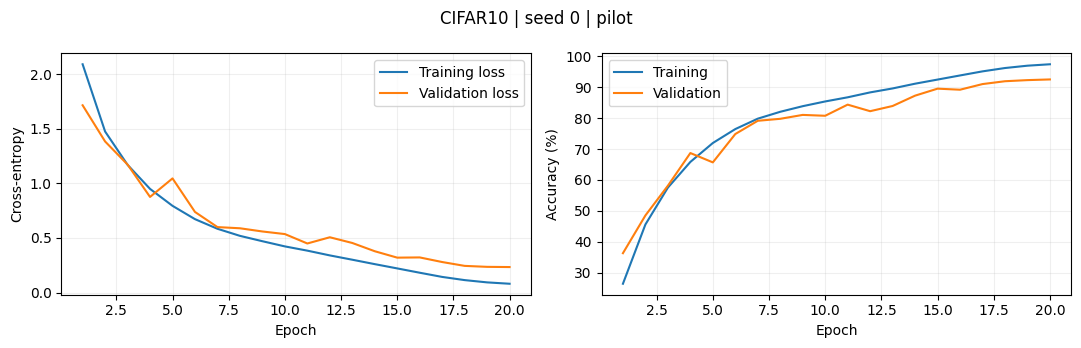

### Training CIFAR100 — seed 0

100%|██████████| 169M/169M [13:27<00:00, 209kB/s]


epoch   1/20: train=11.55% val=17.28% loss=3.7936 (23.3s)
epoch   2/20: train=24.12% val=28.02% loss=3.0367 (24.0s)
epoch   3/20: train=35.28% val=38.48% loss=2.4616 (23.7s)
epoch   4/20: train=43.37% val=42.48% loss=2.0834 (24.4s)
epoch   5/20: train=49.11% val=45.12% loss=1.8328 (24.4s)
epoch   6/20: train=53.29% val=48.06% loss=1.6561 (23.4s)
epoch   7/20: train=56.81% val=51.20% loss=1.5222 (24.0s)
epoch   8/20: train=59.76% val=51.58% loss=1.4093 (24.6s)
epoch   9/20: train=62.61% val=54.44% loss=1.2981 (24.6s)
epoch  10/20: train=65.08% val=54.26% loss=1.1916 (24.7s)
epoch  11/20: train=68.21% val=59.98% loss=1.0839 (24.6s)
epoch  12/20: train=71.08% val=59.60% loss=0.9748 (25.1s)
epoch  13/20: train=74.40% val=64.48% loss=0.8569 (24.7s)
epoch  14/20: train=77.79% val=66.08% loss=0.7412 (25.0s)
epoch  15/20: train=81.39% val=67.74% loss=0.6119 (24.5s)
epoch  16/20: train=85.07% val=69.34% loss=0.4951 (24.4s)
epoch  17/20: train=88.66% val=70.54% loss=0.3858 (24.7s)
epoch  18/20: 

,dataset,seed,method,stage,profile,accuracy,test_n,test_loss,best_epoch
0,cifar100,0,Original,baseline,pilot,72.5,10000,1.029311,20


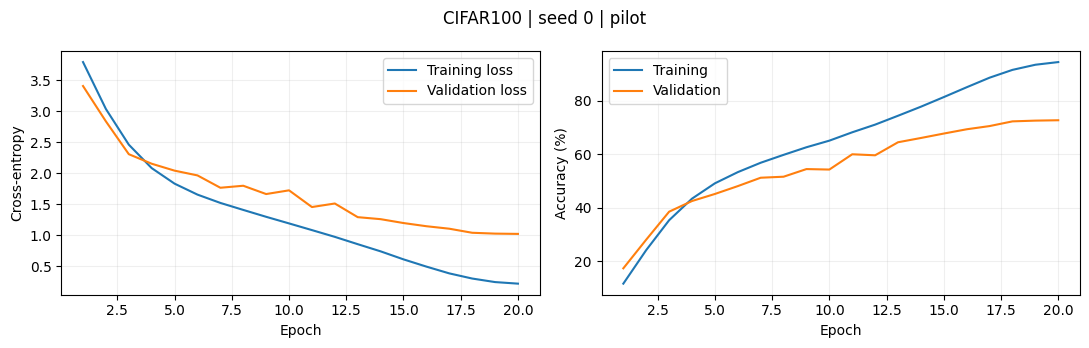

,dataset,method,mean,std,n
0,cifar10,Original,91.84,NaN,1
1,cifar100,Original,72.50,NaN,1


In [ ]:
EXP.baseline_train()

### 7. Compression versus accuracy — before fine-tuning

For each target budget and method, this cell creates a genuinely factorized network and evaluates the entire official test set. It reports test accuracy, both actual cost reductions, unused budget, and actual local error. Calibration statistics are collected from the original frozen network, not from a progressively modified network.

The measured local error of the deployed float32 factors is also checked against its corresponding analytic projection objective. Ordinary-SVD factors are evaluated using their own actual activation errors, not the activation-weighted optimum's spectral tail.

cifar10 seed 0 | SVD-uniform | target 50% | actual params 50.24% / MACs 50.48% | test accuracy 89.06%
cifar10 seed 0 | SVD-weight-greedy | target 50% | actual params 50.00% / MACs 55.05% | test accuracy 13.47%
cifar10 seed 0 | SVD-activation-greedy | target 50% | actual params 50.01% / MACs 24.54% | test accuracy 91.11%
cifar10 seed 0 | SVD-random | target 50% | actual params 50.00% / MACs 78.50% | test accuracy 10.34%
cifar10 seed 0 | AW-uniform | target 50% | actual params 50.24% / MACs 50.48% | test accuracy 91.11%
cifar10 seed 0 | AW-greedy | target 50% | actual params 50.00% / MACs 22.92% | test accuracy 91.62%
cifar10 seed 0 | AW-relative-greedy | target 50% | actual params 50.03% / MACs 16.10% | test accuracy 91.75%


,dataset,seed,method,accuracy,parameter_reduction,mac_reduction,E_A,unused_budget
0,cifar10,0,SVD-uniform,89.06,0.502366,0.504840,7.364395,26427
1,cifar10,0,SVD-weight-greedy,13.47,0.500045,0.550548,82.481608,507
2,cifar10,0,SVD-activation-greedy,91.11,0.500051,0.245448,8.252707,571
3,cifar10,0,SVD-random,10.34,0.500017,0.784956,105.347110,187
4,cifar10,0,AW-uniform,91.11,0.502366,0.504840,2.509134,26427
5,cifar10,0,AW-greedy,91.62,0.500005,0.229172,2.263541,59
6,cifar10,0,AW-relative-greedy,91.75,0.500303,0.160972,1.668199,3387


cifar10 seed 0 | SVD-uniform | target 70% | actual params 70.16% / MACs 70.70% | test accuracy 78.00%
cifar10 seed 0 | SVD-weight-greedy | target 70% | actual params 70.00% / MACs 74.30% | test accuracy 10.00%
cifar10 seed 0 | SVD-activation-greedy | target 70% | actual params 70.00% / MACs 39.58% | test accuracy 90.08%
cifar10 seed 0 | SVD-random | target 70% | actual params 70.04% / MACs 89.32% | test accuracy 10.00%
cifar10 seed 0 | AW-uniform | target 70% | actual params 70.16% / MACs 70.70% | test accuracy 88.11%
cifar10 seed 0 | AW-greedy | target 70% | actual params 70.00% / MACs 38.49% | test accuracy 91.26%
cifar10 seed 0 | AW-relative-greedy | target 70% | actual params 70.00% / MACs 29.80% | test accuracy 91.23%


,dataset,seed,method,accuracy,parameter_reduction,mac_reduction,E_A,unused_budget
0,cifar10,0,SVD-uniform,78.00,0.701640,0.706970,18.214446,18322
1,cifar10,0,SVD-weight-greedy,10.00,0.700025,0.742965,132.746625,274
2,cifar10,0,SVD-activation-greedy,90.08,0.700002,0.395771,15.420900,18
3,cifar10,0,SVD-random,10.00,0.700408,0.893237,147.530761,4562
4,cifar10,0,AW-uniform,88.11,0.701640,0.706970,7.569025,18322
5,cifar10,0,AW-greedy,91.26,0.700042,0.384915,5.648017,466
6,cifar10,0,AW-relative-greedy,91.23,0.700019,0.298006,9.219983,210


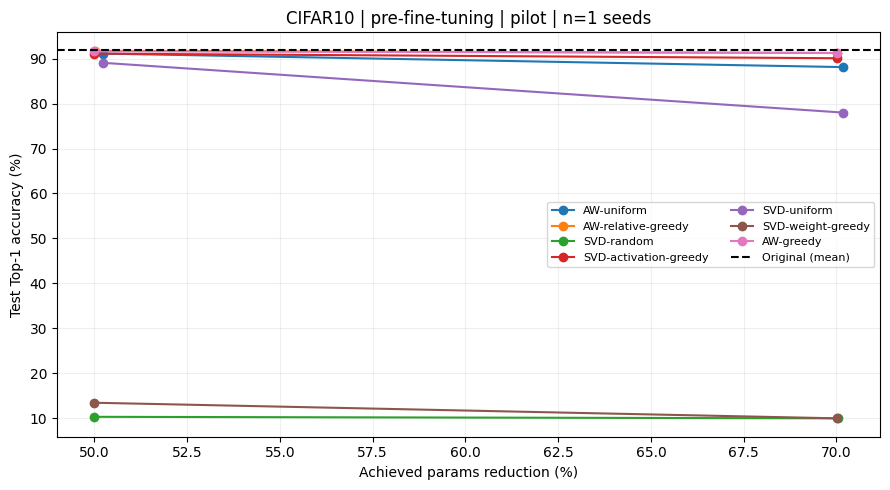

cifar100 seed 0 | SVD-uniform | target 50% | actual params 50.03% / MACs 50.48% | test accuracy 68.99%
cifar100 seed 0 | SVD-weight-greedy | target 50% | actual params 50.00% / MACs 74.66% | test accuracy 1.00%
cifar100 seed 0 | SVD-activation-greedy | target 50% | actual params 50.01% / MACs 39.25% | test accuracy 60.09%
cifar100 seed 0 | SVD-random | target 50% | actual params 50.03% / MACs 78.61% | test accuracy 0.99%
cifar100 seed 0 | AW-uniform | target 50% | actual params 50.03% / MACs 50.48% | test accuracy 70.78%
cifar100 seed 0 | AW-greedy | target 50% | actual params 50.00% / MACs 44.57% | test accuracy 63.75%
cifar100 seed 0 | AW-relative-greedy | target 50% | actual params 50.00% / MACs 18.90% | test accuracy 70.40%


,dataset,seed,method,accuracy,parameter_reduction,mac_reduction,E_A,unused_budget
0,cifar100,0,SVD-uniform,68.99,0.500298,0.504799,18.175336,3342
1,cifar100,0,SVD-weight-greedy,1.00,0.500041,0.746590,173.507780,462
2,cifar100,0,SVD-activation-greedy,60.09,0.500053,0.392456,26.461759,590
3,cifar100,0,SVD-random,0.99,0.500264,0.786100,150.998583,2958
4,cifar100,0,AW-uniform,70.78,0.500298,0.504799,8.771288,3342
5,cifar100,0,AW-greedy,63.75,0.500007,0.445711,13.849809,78
6,cifar100,0,AW-relative-greedy,70.40,0.500047,0.188950,25.001182,526


cifar100 seed 0 | SVD-uniform | target 70% | actual params 70.04% / MACs 70.74% | test accuracy 51.83%
cifar100 seed 0 | SVD-weight-greedy | target 70% | actual params 70.00% / MACs 89.00% | test accuracy 1.00%
cifar100 seed 0 | SVD-activation-greedy | target 70% | actual params 70.00% / MACs 67.32% | test accuracy 6.92%
cifar100 seed 0 | SVD-random | target 70% | actual params 70.03% / MACs 89.40% | test accuracy 1.00%
cifar100 seed 0 | AW-uniform | target 70% | actual params 70.04% / MACs 70.74% | test accuracy 64.96%
cifar100 seed 0 | AW-greedy | target 70% | actual params 70.01% / MACs 74.94% | test accuracy 26.63%
cifar100 seed 0 | AW-relative-greedy | target 70% | actual params 70.00% / MACs 36.48% | test accuracy 62.41%


,dataset,seed,method,accuracy,parameter_reduction,mac_reduction,E_A,unused_budget
0,cifar100,0,SVD-uniform,51.83,0.700373,0.707435,44.804426,4179
1,cifar100,0,SVD-weight-greedy,1.00,0.700013,0.889984,213.420774,147
2,cifar100,0,SVD-activation-greedy,6.92,0.700002,0.673220,93.460743,19
3,cifar100,0,SVD-random,1.00,0.700264,0.894047,215.421037,2963
4,cifar100,0,AW-uniform,64.96,0.700373,0.707435,23.287013,4179
5,cifar100,0,AW-greedy,26.63,0.700053,0.749407,51.408844,595
6,cifar100,0,AW-relative-greedy,62.41,0.700002,0.364753,53.705026,19


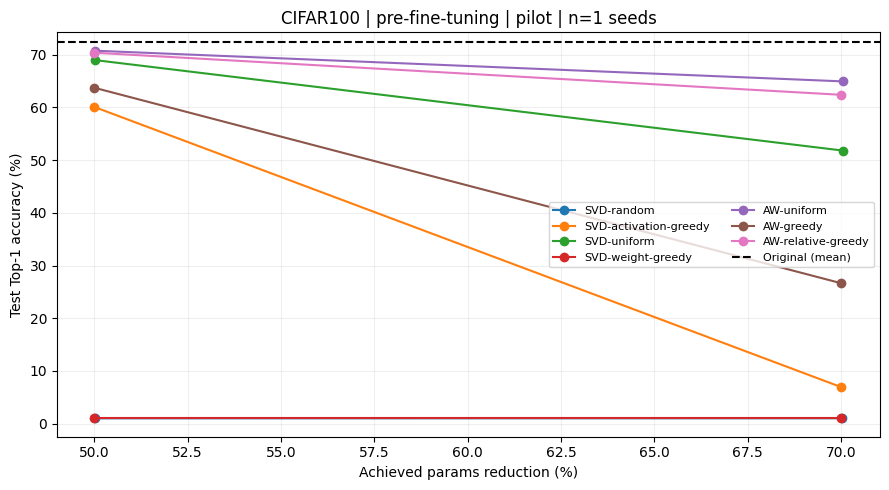

,dataset,method,target_reduction,mean,std,n
0,cifar10,AW-greedy,0.5,91.62,NaN,1
1,cifar10,AW-greedy,0.7,91.26,NaN,1
2,cifar10,AW-relative-greedy,0.5,91.75,NaN,1
3,cifar10,AW-relative-greedy,0.7,91.23,NaN,1
4,cifar10,AW-uniform,0.5,91.11,NaN,1
5,cifar10,AW-uniform,0.7,88.11,NaN,1
6,cifar10,SVD-activation-greedy,0.5,91.11,NaN,1
7,cifar10,SVD-activation-greedy,0.7,90.08,NaN,1
8,cifar10,SVD-random,0.5,10.34,NaN,1
9,cifar10,SVD-random,0.7,10.00,NaN,1


In [ ]:
EXP.compression_study()

### 8. Does local error predict accuracy loss?

At each **fixed target budget, dataset, checkpoint seed, and factorization basis**, generate distinct seeded random feasible rank vectors. The same rank vectors are used for the SVD and AW families. For every resulting model, measure both
$$
E_W=\sum_\ell\|W_\ell-\widetilde W_\ell\|_F^2,
\qquad E_A=\sum_\ell\widehat E_\ell,
$$
and evaluate validation accuracy. Weight-error and activation-error correlations therefore use the **same configurations**, rather than separately selected models. The normalized-error variant is also reported.

Pearson and Spearman correlations are computed within each group; budgets and factor families are not pooled. Exact achieved costs and leftover budget are stored because integer ranks do not usually attain the target exactly. Remaining achieved-cost variation is a limitation of the fixed-target design.

cifar10 seed 0 | random-svd | target 50% | actual params 50.00% / MACs 78.50% | val accuracy 10.38%
cifar10 seed 0 | random-aw | target 50% | actual params 50.00% / MACs 78.50% | val accuracy 5.56%
cifar10 seed 0 | random-svd | target 50% | actual params 50.02% / MACs 78.88% | val accuracy 10.04%
cifar10 seed 0 | random-aw | target 50% | actual params 50.02% / MACs 78.88% | val accuracy 5.78%
cifar10 seed 0 | random-svd | target 50% | actual params 50.05% / MACs 79.25% | val accuracy 10.04%
cifar10 seed 0 | random-aw | target 50% | actual params 50.05% / MACs 79.25% | val accuracy 8.94%
cifar10 seed 0 | random-svd | target 50% | actual params 50.01% / MACs 78.51% | val accuracy 9.98%
cifar10 seed 0 | random-aw | target 50% | actual params 50.01% / MACs 78.51% | val accuracy 9.98%
cifar10 seed 0 | random-svd | target 50% | actual params 50.01% / MACs 78.30% | val accuracy 10.14%
cifar10 seed 0 | random-aw | target 50% | actual params 50.01% / MACs 78.30% | val accuracy 6.84%
cifar10 see

,dataset,seed,target_reduction,basis,metric,pearson,spearman,n_configurations,reason
0,cifar10,0,0.5,aw,E_W,0.321683,0.095238,8,None
1,cifar10,0,0.5,aw,E_A,0.711208,0.404762,8,None
2,cifar10,0,0.5,aw,E_relative,0.603665,0.404762,8,None
3,cifar10,0,0.5,svd,E_W,0.779077,0.317168,8,None
4,cifar10,0,0.5,svd,E_A,0.552551,0.292770,8,None
5,cifar10,0,0.5,svd,E_relative,0.567551,0.292770,8,None


cifar10 seed 0 | random-svd | target 70% | actual params 70.04% / MACs 89.32% | val accuracy 10.00%
cifar10 seed 0 | random-aw | target 70% | actual params 70.04% / MACs 89.32% | val accuracy 10.00%
cifar10 seed 0 | random-svd | target 70% | actual params 70.04% / MACs 89.32% | val accuracy 10.00%
cifar10 seed 0 | random-aw | target 70% | actual params 70.04% / MACs 89.32% | val accuracy 10.00%
cifar10 seed 0 | random-svd | target 70% | actual params 70.01% / MACs 89.31% | val accuracy 10.00%
cifar10 seed 0 | random-aw | target 70% | actual params 70.01% / MACs 89.31% | val accuracy 10.00%
cifar10 seed 0 | random-svd | target 70% | actual params 70.02% / MACs 89.30% | val accuracy 10.00%
cifar10 seed 0 | random-aw | target 70% | actual params 70.02% / MACs 89.30% | val accuracy 10.00%
cifar10 seed 0 | random-svd | target 70% | actual params 70.04% / MACs 89.32% | val accuracy 10.00%
cifar10 seed 0 | random-aw | target 70% | actual params 70.04% / MACs 89.32% | val accuracy 10.00%
cifar

,dataset,seed,target_reduction,basis,metric,pearson,spearman,n_configurations,reason
0,cifar10,0,0.7,aw,E_W,NaN,NaN,8,constant accuracy drop
1,cifar10,0,0.7,aw,E_A,NaN,NaN,8,constant accuracy drop
2,cifar10,0,0.7,aw,E_relative,NaN,NaN,8,constant accuracy drop
3,cifar10,0,0.7,svd,E_W,NaN,NaN,8,constant accuracy drop
4,cifar10,0,0.7,svd,E_A,NaN,NaN,8,constant accuracy drop
5,cifar10,0,0.7,svd,E_relative,NaN,NaN,8,constant accuracy drop


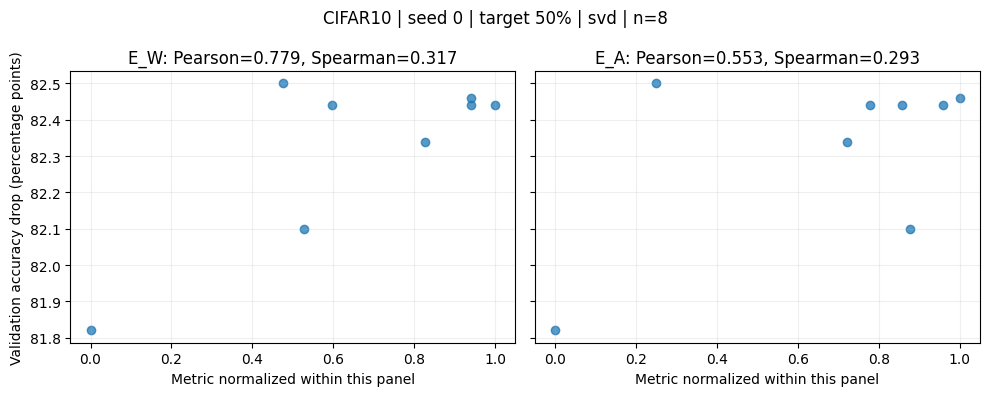

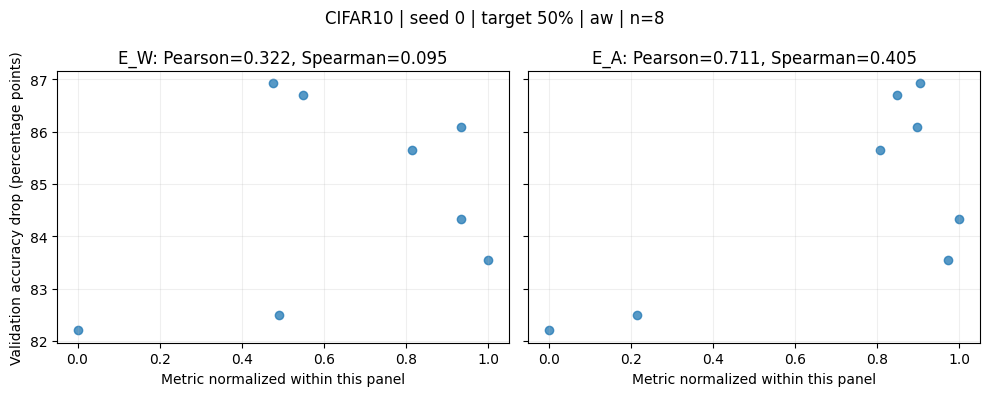

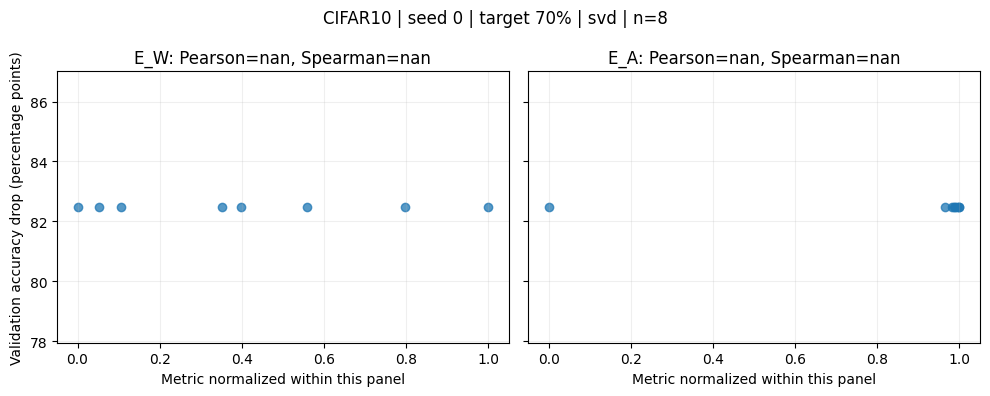

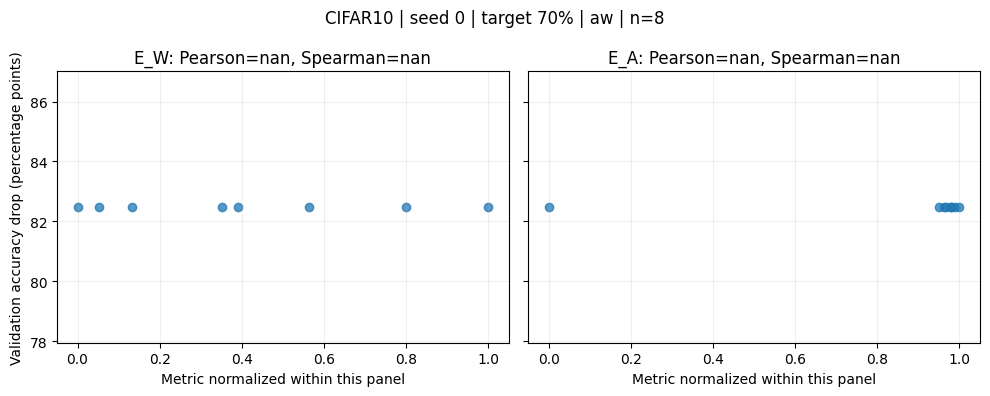

cifar100 seed 0 | random-svd | target 50% | actual params 50.03% / MACs 78.61% | val accuracy 1.00%
cifar100 seed 0 | random-aw | target 50% | actual params 50.03% / MACs 78.61% | val accuracy 1.00%
cifar100 seed 0 | random-svd | target 50% | actual params 50.04% / MACs 79.00% | val accuracy 1.00%
cifar100 seed 0 | random-aw | target 50% | actual params 50.04% / MACs 79.00% | val accuracy 1.00%
cifar100 seed 0 | random-svd | target 50% | actual params 50.00% / MACs 79.38% | val accuracy 0.74%
cifar100 seed 0 | random-aw | target 50% | actual params 50.00% / MACs 79.38% | val accuracy 1.04%
cifar100 seed 0 | random-svd | target 50% | actual params 50.02% / MACs 78.57% | val accuracy 1.00%
cifar100 seed 0 | random-aw | target 50% | actual params 50.02% / MACs 78.57% | val accuracy 1.00%
cifar100 seed 0 | random-svd | target 50% | actual params 50.03% / MACs 78.44% | val accuracy 0.98%
cifar100 seed 0 | random-aw | target 50% | actual params 50.03% / MACs 78.44% | val accuracy 1.10%
cifar

,dataset,seed,target_reduction,basis,metric,pearson,spearman,n_configurations,reason
0,cifar100,0,0.5,aw,E_W,-0.402191,-0.681931,8,None
1,cifar100,0,0.5,aw,E_A,-0.007959,0.245495,8,None
2,cifar100,0,0.5,aw,E_relative,0.048050,0.081832,8,None
3,cifar100,0,0.5,svd,E_W,0.186540,0.456612,8,None
4,cifar100,0,0.5,svd,E_A,0.119298,0.469295,8,None
5,cifar100,0,0.5,svd,E_relative,0.220349,0.469295,8,None


cifar100 seed 0 | random-svd | target 70% | actual params 70.03% / MACs 89.40% | val accuracy 1.00%
cifar100 seed 0 | random-aw | target 70% | actual params 70.03% / MACs 89.40% | val accuracy 1.00%
cifar100 seed 0 | random-svd | target 70% | actual params 70.03% / MACs 89.41% | val accuracy 1.00%
cifar100 seed 0 | random-aw | target 70% | actual params 70.03% / MACs 89.41% | val accuracy 1.00%
cifar100 seed 0 | random-svd | target 70% | actual params 70.00% / MACs 89.40% | val accuracy 1.00%
cifar100 seed 0 | random-aw | target 70% | actual params 70.00% / MACs 89.40% | val accuracy 1.00%
cifar100 seed 0 | random-svd | target 70% | actual params 70.03% / MACs 89.41% | val accuracy 1.00%
cifar100 seed 0 | random-aw | target 70% | actual params 70.03% / MACs 89.41% | val accuracy 1.00%
cifar100 seed 0 | random-svd | target 70% | actual params 70.01% / MACs 89.40% | val accuracy 1.00%
cifar100 seed 0 | random-aw | target 70% | actual params 70.01% / MACs 89.40% | val accuracy 1.00%
cifar

,dataset,seed,target_reduction,basis,metric,pearson,spearman,n_configurations,reason
0,cifar100,0,0.7,aw,E_W,NaN,NaN,8,constant accuracy drop
1,cifar100,0,0.7,aw,E_A,NaN,NaN,8,constant accuracy drop
2,cifar100,0,0.7,aw,E_relative,NaN,NaN,8,constant accuracy drop
3,cifar100,0,0.7,svd,E_W,NaN,NaN,8,constant accuracy drop
4,cifar100,0,0.7,svd,E_A,NaN,NaN,8,constant accuracy drop
5,cifar100,0,0.7,svd,E_relative,NaN,NaN,8,constant accuracy drop


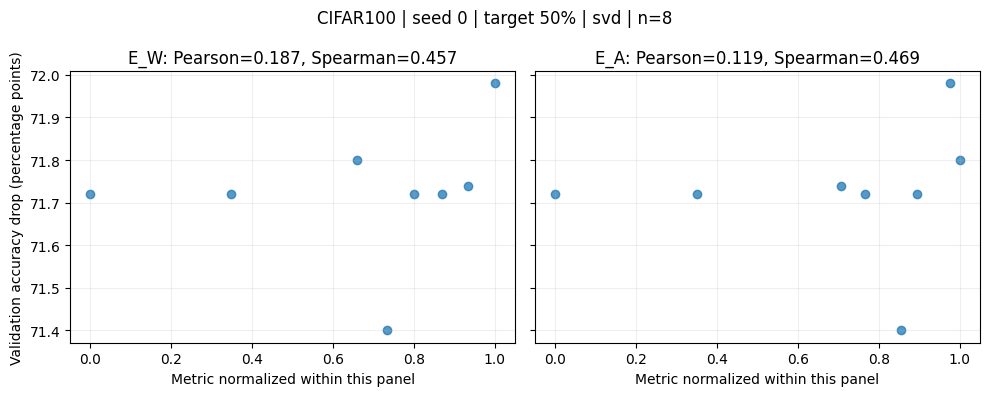

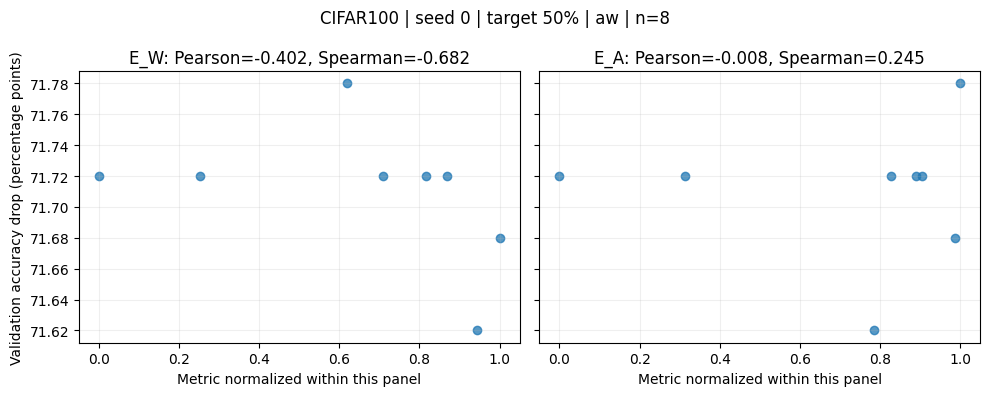

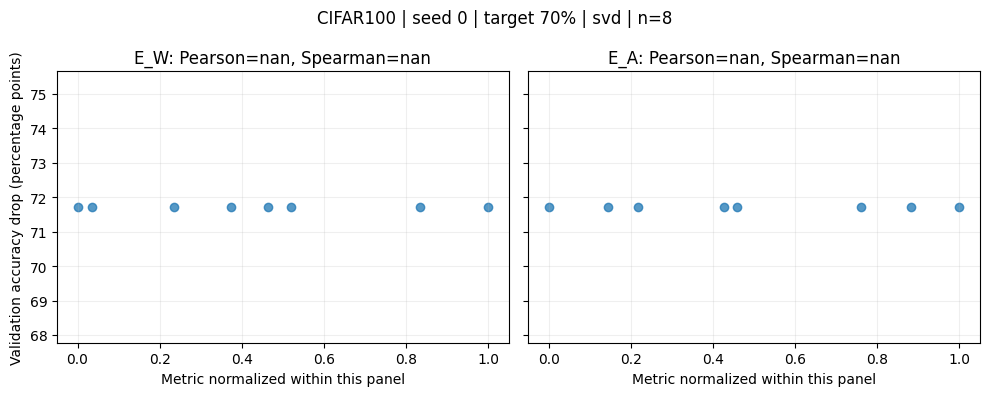

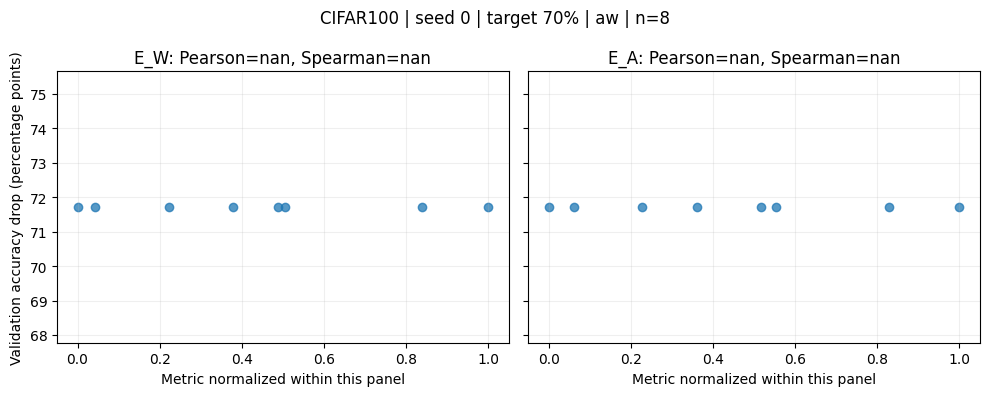

,dataset,seed,target_reduction,basis,metric,pearson,spearman,n_configurations,reason
0,cifar10,0,0.5,aw,E_W,0.321683,0.095238,8,None
1,cifar10,0,0.5,aw,E_A,0.711208,0.404762,8,None
2,cifar10,0,0.5,aw,E_relative,0.603665,0.404762,8,None
3,cifar10,0,0.5,svd,E_W,0.779077,0.317168,8,None
4,cifar10,0,0.5,svd,E_A,0.552551,0.292770,8,None
5,cifar10,0,0.5,svd,E_relative,0.567551,0.292770,8,None
6,cifar10,0,0.7,aw,E_W,NaN,NaN,8,constant accuracy drop
7,cifar10,0,0.7,aw,E_A,NaN,NaN,8,constant accuracy drop
8,cifar10,0,0.7,aw,E_relative,NaN,NaN,8,constant accuracy drop
9,cifar10,0,0.7,svd,E_W,NaN,NaN,8,constant accuracy drop


**Pearson across independent checkpoint seeds**

,dataset,target_reduction,basis,metric,mean,std,n
0,cifar10,0.5,aw,E_A,0.711208,NaN,1
1,cifar10,0.5,aw,E_W,0.321683,NaN,1
2,cifar10,0.5,aw,E_relative,0.603665,NaN,1
3,cifar10,0.5,svd,E_A,0.552551,NaN,1
4,cifar10,0.5,svd,E_W,0.779077,NaN,1
5,cifar10,0.5,svd,E_relative,0.567551,NaN,1
6,cifar10,0.7,aw,E_A,NaN,NaN,0
7,cifar10,0.7,aw,E_W,NaN,NaN,0
8,cifar10,0.7,aw,E_relative,NaN,NaN,0
9,cifar10,0.7,svd,E_A,NaN,NaN,0


**Spearman across independent checkpoint seeds**

,dataset,target_reduction,basis,metric,mean,std,n
0,cifar10,0.5,aw,E_A,0.404762,NaN,1
1,cifar10,0.5,aw,E_W,0.095238,NaN,1
2,cifar10,0.5,aw,E_relative,0.404762,NaN,1
3,cifar10,0.5,svd,E_A,0.292770,NaN,1
4,cifar10,0.5,svd,E_W,0.317168,NaN,1
5,cifar10,0.5,svd,E_relative,0.292770,NaN,1
6,cifar10,0.7,aw,E_A,NaN,NaN,0
7,cifar10,0.7,aw,E_W,NaN,NaN,0
8,cifar10,0.7,aw,E_relative,NaN,NaN,0
9,cifar10,0.7,svd,E_A,NaN,NaN,0


In [ ]:
EXP.metric_study()

### 9. Calibration-size ablation

Use **nested unlabeled training-image subsets** of the configured sizes, with fixed image order and patch-sampling seeds. Recompute the moments, factors, and ranks for each size at the configured ablation budget. This evaluates both `AW-greedy` and the normalized variant on the real test split.

cifar10 seed 0 | AW-greedy | target 70% | actual params 70.00% / MACs 38.70% | test accuracy 90.88%


,dataset,seed,method,calibration_images,accuracy,parameter_reduction,mac_reduction
0,cifar10,0,AW-greedy,100,90.88,0.70003,0.386958


cifar10 seed 0 | AW-relative-greedy | target 70% | actual params 70.00% / MACs 28.41% | test accuracy 91.08%


,dataset,seed,method,calibration_images,accuracy,parameter_reduction,mac_reduction
0,cifar10,0,AW-relative-greedy,100,91.08,0.700042,0.284076


cifar10 seed 0 | AW-greedy | target 70% | actual params 70.00% / MACs 38.58% | test accuracy 91.17%


...

,dataset,seed,method,calibration_images,accuracy,parameter_reduction,mac_reduction
0,cifar10,0,AW-relative-greedy,1000,91.23,0.700019,0.298006


cifar10 seed 0 | AW-greedy | target 70% | actual params 70.00% / MACs 38.79% | test accuracy 91.24%


,dataset,seed,method,calibration_images,accuracy,parameter_reduction,mac_reduction
0,cifar10,0,AW-greedy,5000,91.24,0.700007,0.387946


cifar10 seed 0 | AW-relative-greedy | target 70% | actual params 70.00% / MACs 29.78% | test accuracy 91.13%


,dataset,seed,method,calibration_images,accuracy,parameter_reduction,mac_reduction
0,cifar10,0,AW-relative-greedy,5000,91.13,0.700042,0.297792


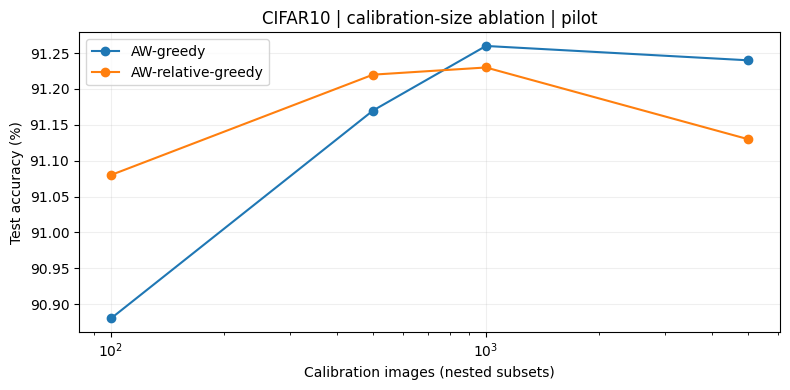

cifar100 seed 0 | AW-greedy | target 70% | actual params 70.00% / MACs 54.85% | test accuracy 57.07%


,dataset,seed,method,calibration_images,accuracy,parameter_reduction,mac_reduction
0,cifar100,0,AW-greedy,100,57.07,0.700007,0.54846


cifar100 seed 0 | AW-relative-greedy | target 70% | actual params 70.00% / MACs 34.03% | test accuracy 56.65%


,dataset,seed,method,calibration_images,accuracy,parameter_reduction,mac_reduction
0,cifar100,0,AW-relative-greedy,100,56.65,0.70003,0.340256


cifar100 seed 0 | AW-greedy | target 70% | actual params 70.00% / MACs 73.86% | test accuracy 31.16%


...

,dataset,seed,method,calibration_images,accuracy,parameter_reduction,mac_reduction
0,cifar100,0,AW-relative-greedy,1000,62.41,0.700002,0.364753


cifar100 seed 0 | AW-greedy | target 70% | actual params 70.01% / MACs 75.58% | test accuracy 22.39%


,dataset,seed,method,calibration_images,accuracy,parameter_reduction,mac_reduction
0,cifar100,0,AW-greedy,5000,22.39,0.700053,0.755778


cifar100 seed 0 | AW-relative-greedy | target 70% | actual params 70.00% / MACs 36.41% | test accuracy 62.58%


,dataset,seed,method,calibration_images,accuracy,parameter_reduction,mac_reduction
0,cifar100,0,AW-relative-greedy,5000,62.58,0.700025,0.364096


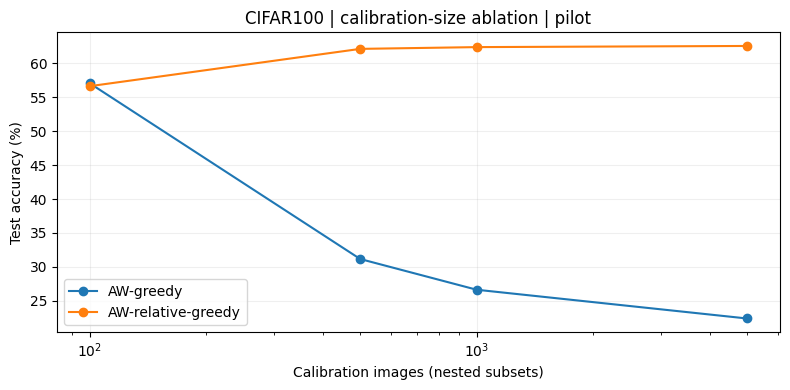

,dataset,method,calibration_images,mean,std,n
0,cifar10,AW-greedy,100,90.88,NaN,1
1,cifar10,AW-greedy,500,91.17,NaN,1
2,cifar10,AW-greedy,1000,91.26,NaN,1
3,cifar10,AW-greedy,5000,91.24,NaN,1
4,cifar10,AW-relative-greedy,100,91.08,NaN,1
5,cifar10,AW-relative-greedy,500,91.22,NaN,1
6,cifar10,AW-relative-greedy,1000,91.23,NaN,1
7,cifar10,AW-relative-greedy,5000,91.13,NaN,1
8,cifar100,AW-greedy,100,57.07,NaN,1
9,cifar100,AW-greedy,500,31.16,NaN,1


In [ ]:
EXP.calibration_study()

### 10. Batch-normalization folding ablation

Compare `AW-greedy` with raw convolutions and with folded Conv–BN operators, before fine-tuning. Both original networks implement the same evaluation function to numerical tolerance. Their local distortion objectives differ because folding incorporates the BN scale.

Each uses its own explicit whole-model cost denominator. BN affine parameters become convolution biases after folding, so original parameter counts can differ slightly. Read the achieved parameter/MAC columns rather than assuming equal integer parameter totals. The main comparisons apply the same folding choice to every method.

In [ ]:
EXP.bn_study()

### 11. Optional recovery by matched fine-tuning

For all seven methods at the ablation budget, start from their measured compressed initialization, use the same training examples, epoch count, data-order seed, optimizer, and learning-rate schedule, and choose the best epoch using validation only. The test set is evaluated after that selection. BN running statistics, if any remain, are frozen; affine parameters remain trainable.

This is a separate experimental condition from zero-shot compression. It is not included silently in the earlier tables. A negative measured gain is retained. Saved `pre_E_A` and `pre_E_W` describe the initialization, not the updated fine-tuned factors. Model costs are verified to remain unchanged. Set `fine_tune_epochs=0` before starting to omit this study.

epoch   1/3: train=93.46% val=89.66% loss=0.1882 (24.1s)
epoch   2/3: train=94.62% val=90.20% loss=0.1515 (24.4s)
epoch   3/3: train=95.32% val=90.98% loss=0.1314 (24.4s)


,dataset,seed,method,target_reduction,stage,profile,accuracy,before_accuracy,gain_points,eval_n,parameter_reduction,mac_reduction,best_ft_epoch,pre_E_A,pre_E_W
0,cifar10,0,SVD-uniform,0.7,fine_tuning,pilot,90.29,78.0,12.29,10000,0.70164,0.70697,3,18.214446,900.317298


epoch   1/3: train=18.65% val=23.60% loss=2.1903 (25.6s)
epoch   2/3: train=25.61% val=28.48% loss=1.9439 (23.3s)
epoch   3/3: train=28.58% val=28.58% loss=1.8574 (23.1s)


,dataset,seed,method,target_reduction,stage,profile,accuracy,before_accuracy,gain_points,eval_n,parameter_reduction,mac_reduction,best_ft_epoch,pre_E_A,pre_E_W
0,cifar10,0,SVD-weight-greedy,0.7,fine_tuning,pilot,29.7,10.0,19.7,10000,0.700025,0.742965,3,132.746625,886.923508


epoch   1/3: train=95.92% val=91.16% loss=0.1191 (23.6s)
epoch   2/3: train=96.32% val=91.68% loss=0.1062 (22.6s)
epoch   3/3: train=96.78% val=91.72% loss=0.0929 (23.0s)


...

epoch   1/3: train=56.98% val=56.12% loss=1.4847 (23.6s)
epoch   2/3: train=64.36% val=58.54% loss=1.2051 (23.5s)
epoch   3/3: train=67.14% val=60.04% loss=1.1013 (23.6s)


,dataset,seed,method,target_reduction,stage,profile,accuracy,before_accuracy,gain_points,eval_n,parameter_reduction,mac_reduction,best_ft_epoch,pre_E_A,pre_E_W
0,cifar100,0,AW-greedy,0.7,fine_tuning,pilot,59.77,26.63,33.14,10000,0.700053,0.749407,3,51.408844,2855.92939


epoch   1/3: train=79.71% val=66.52% loss=0.6454 (23.3s)
epoch   2/3: train=82.39% val=67.34% loss=0.5518 (23.1s)
epoch   3/3: train=84.30% val=69.14% loss=0.4970 (22.2s)


,dataset,seed,method,target_reduction,stage,profile,accuracy,before_accuracy,gain_points,eval_n,parameter_reduction,mac_reduction,best_ft_epoch,pre_E_A,pre_E_W
0,cifar100,0,AW-relative-greedy,0.7,fine_tuning,pilot,67.79,62.41,5.38,10000,0.700002,0.364753,3,53.705026,6519.819648


,dataset,method,mean,std,n
0,cifar10,AW-greedy,91.33,NaN,1
1,cifar10,AW-relative-greedy,91.42,NaN,1
2,cifar10,AW-uniform,90.16,NaN,1
3,cifar10,SVD-activation-greedy,91.10,NaN,1
4,cifar10,SVD-random,10.00,NaN,1
5,cifar10,SVD-uniform,90.29,NaN,1
6,cifar10,SVD-weight-greedy,29.70,NaN,1
7,cifar100,AW-greedy,59.77,NaN,1
8,cifar100,AW-relative-greedy,67.79,NaN,1
9,cifar100,AW-uniform,69.30,NaN,1


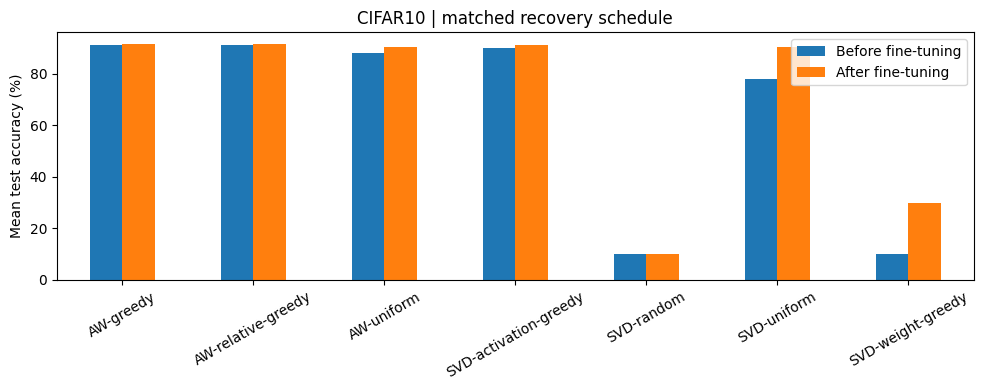

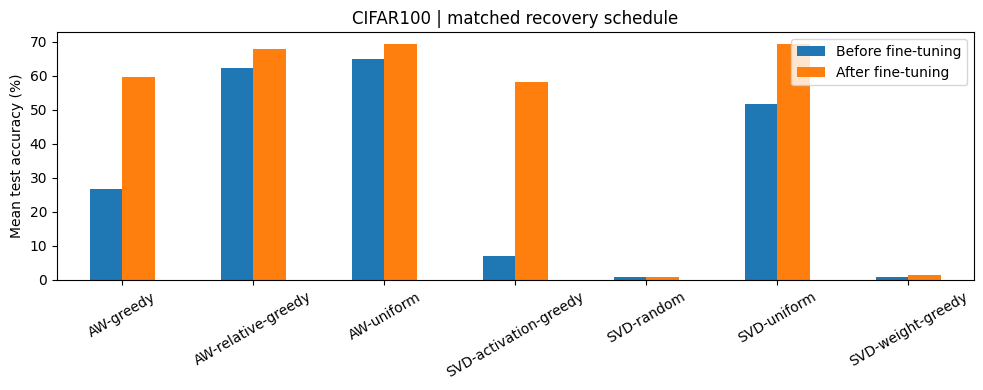

In [ ]:
EXP.fine_tuning_study()

### 12. Review the completed results

Keep the executed notebook with its outputs when reporting results. Compare methods using the same seeds and achieved cost, report `n` and the stated standard deviation, identify the pilot/full profile, distinguish pre- and post-fine-tuning, and report inconclusive or negative findings as measured. Accuracy numbers cannot establish that the local surrogate is globally optimal or universally superior.

In [ ]:
EXP.final_summary()

## Results produced by this run

,profile,run_id,datasets,planned_seeds,baseline_epochs,budget_kind,fold_bn,output_directory
0,pilot,c2543a4fae92,"cifar10, cifar100",1,20,params,True,/content/awpaper_results/pilot_c2543a4fae92


baseline: 2 completed records


,dataset,method,mean,std,n
0,cifar10,Original,91.84,NaN,1
1,cifar100,Original,72.50,NaN,1


compression: 28 completed records


...

bn_ablation: 4 completed records


,dataset,method,target_reduction,calibration_images,fold_bn,mean,std,n
0,cifar10,AW-greedy,0.7,1000,False,90.80,NaN,1
1,cifar10,AW-greedy,0.7,1000,True,91.26,NaN,1
2,cifar100,AW-greedy,0.7,1000,False,9.69,NaN,1
3,cifar100,AW-greedy,0.7,1000,True,26.63,NaN,1


fine_tuning: 14 completed records


,dataset,method,target_reduction,mean,std,n
0,cifar10,AW-greedy,0.7,91.33,NaN,1
1,cifar10,AW-relative-greedy,0.7,91.42,NaN,1
2,cifar10,AW-uniform,0.7,90.16,NaN,1
3,cifar10,SVD-activation-greedy,0.7,91.10,NaN,1
4,cifar10,SVD-random,0.7,10.00,NaN,1
5,cifar10,SVD-uniform,0.7,90.29,NaN,1
6,cifar10,SVD-weight-greedy,0.7,29.70,NaN,1
7,cifar100,AW-greedy,0.7,59.77,NaN,1
8,cifar100,AW-relative-greedy,0.7,67.79,NaN,1
9,cifar100,AW-uniform,0.7,69.30,NaN,1


No archive was created. Results are displayed above and saved as individual CSV/JSON/PNG/PDF files.
Checkpoints allow rerunning the same configuration to resume completed epochs and skip completed experiments.


### Reproducibility notes and primary documentation

- A run ID includes the complete configuration and engine hash. Each resumed runtime records its software versions and device. Seeded training requests deterministic kernels, with warnings for operations lacking a deterministic implementation; bitwise agreement across GPU types or library releases is not promised.
- Completed epochs are written atomically. An interrupted, uncompleted epoch is restarted. Completed experimental records are reused; rerun their cells to display their tables and figures again. Avoid running two notebooks concurrently into the same run folder.
- Full mode contains ten independently trained baseline models and seventy separately fine-tuned compressed models, plus the evaluation and ablation sweeps. Availability, memory, and runtime limits depend on Colab's allocated resources. Save to Drive if a deleted runtime must be recoverable.
- If memory is insufficient, reduce training/evaluation/calibration batch sizes and start a new configuration. Do not silently combine old and new runs. `patches_per_image=None` evaluates the all-position empirical objective at greater cost; it defines a different calibration measure from capped sampling.
- Results are specific to this architecture, recipe, candidate ranks, sampled calibration measure, and nullspace extension.

Primary API references:

- [PyTorch symmetric eigendecomposition](https://docs.pytorch.org/docs/stable/generated/torch.linalg.eigh.html)
- [PyTorch evaluation-mode Conv–BN fusion](https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.fuse_conv_bn_eval.html)
- [torchvision CIFAR-10](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html)
- [torchvision CIFAR-100](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR100.html)
- [Google Colab resource and runtime FAQ](https://research.google.com/colaboratory/faq.html)